# This notebook has all the plots

# Gradient norm plots

## NIFTY DATA

### Seed wise

y axis scale = log

/tmp/ipykernel_8129/3714007886.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


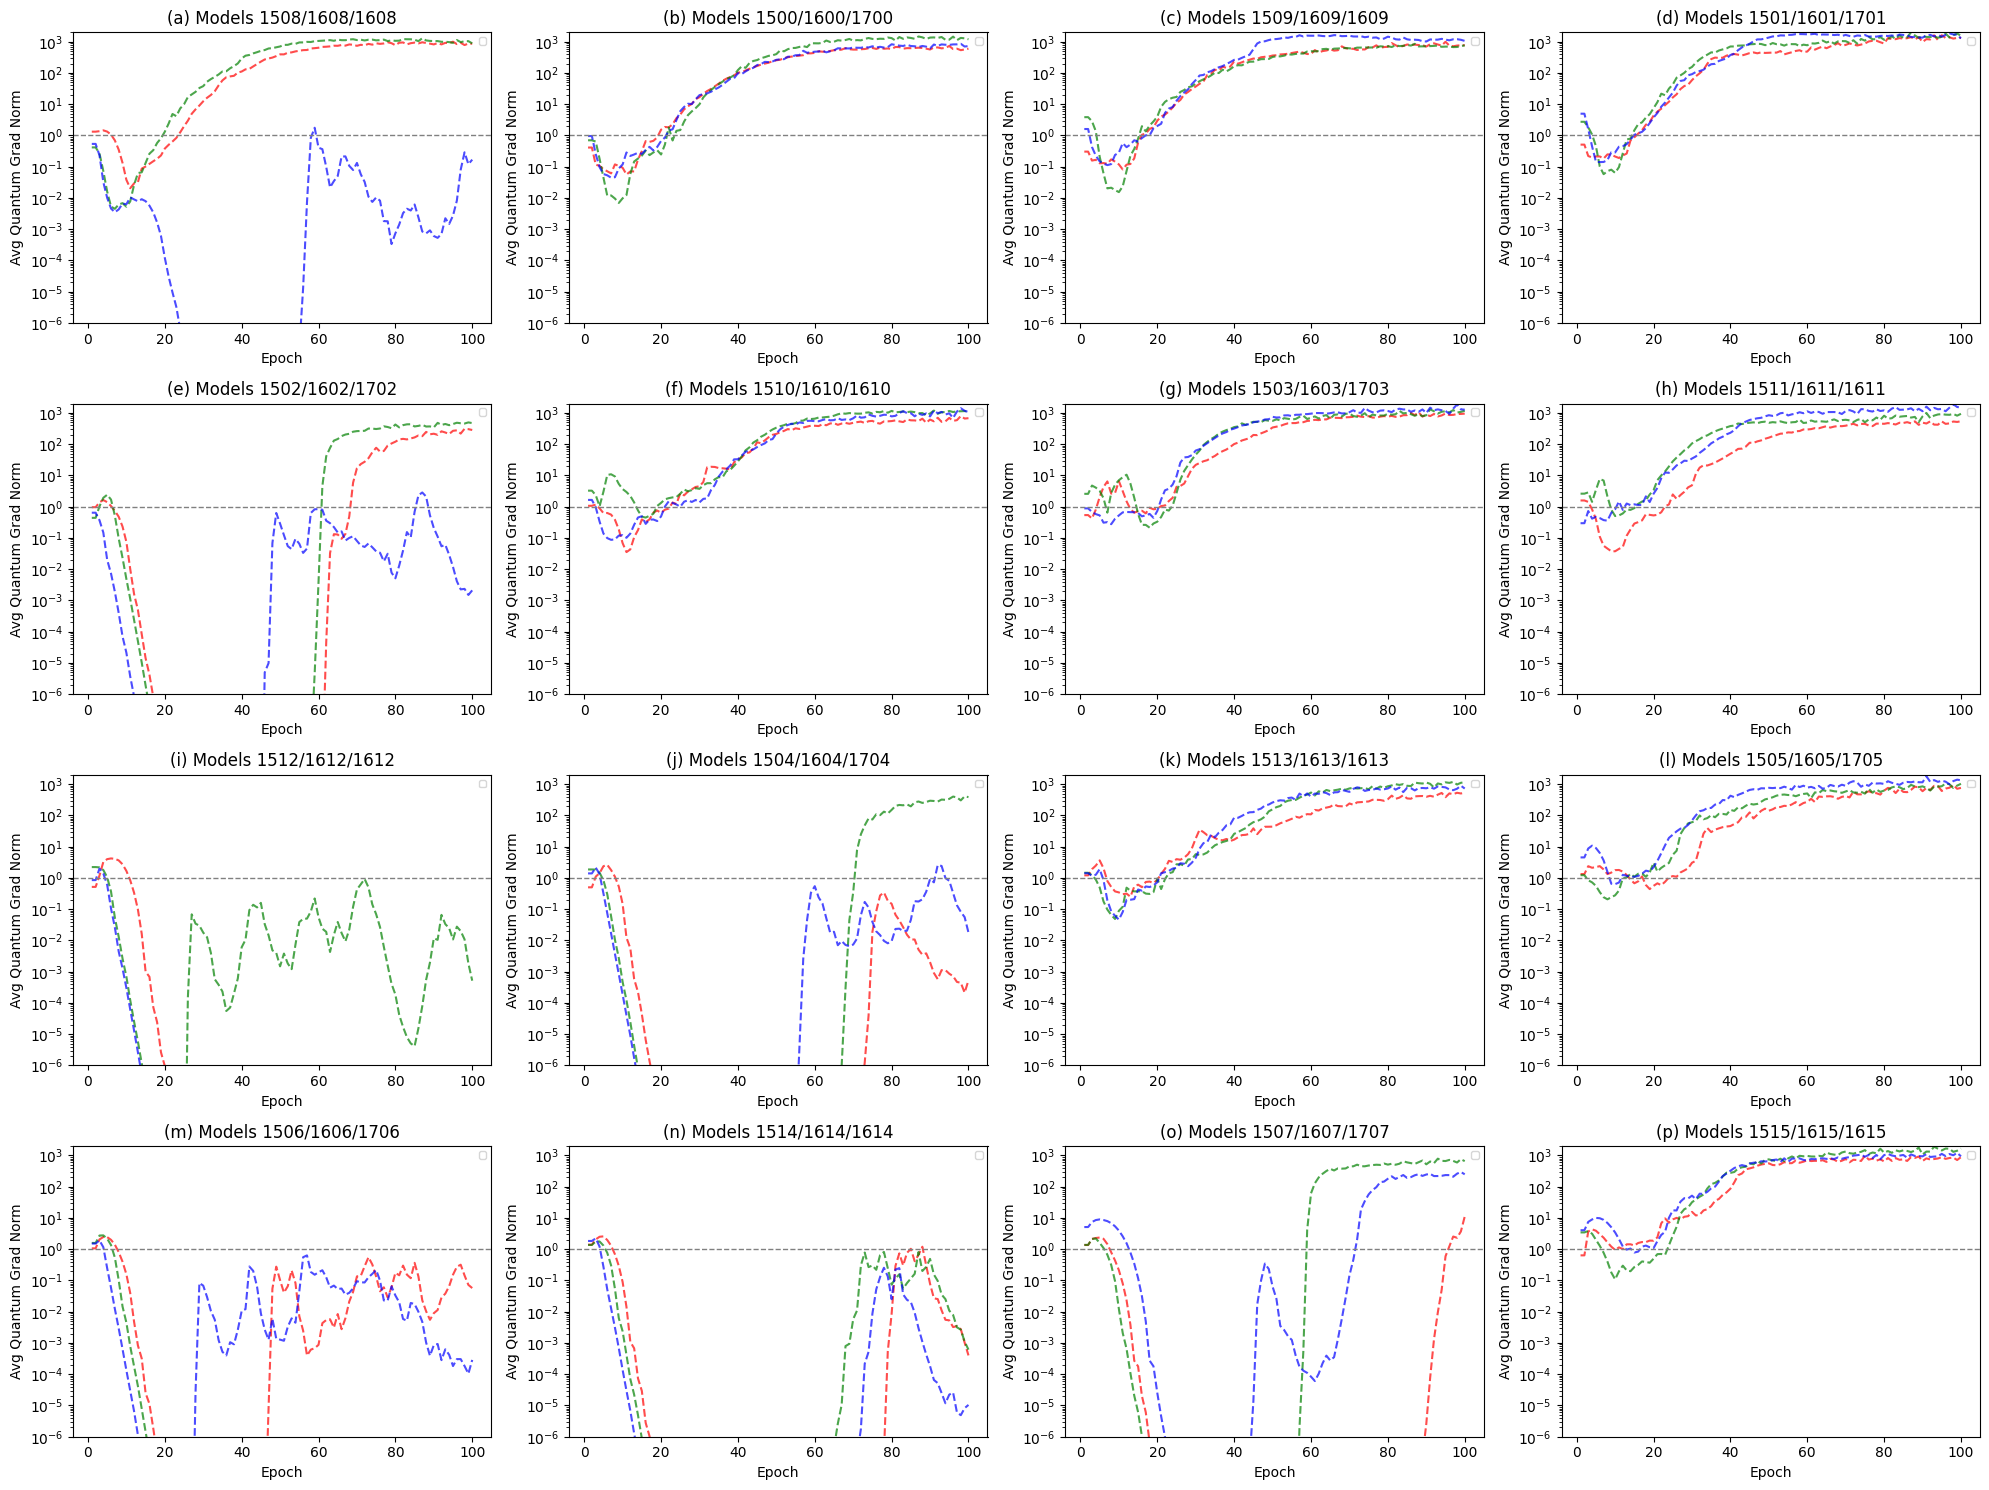

In [71]:
import matplotlib.pyplot as plt
import json
import numpy as np

def impute_nans_with_neighbors(arr):
    arr = np.array(arr, dtype=np.float64)
    n = len(arr)
    for i in range(n):
        if np.isnan(arr[i]):
            prev_idx, next_idx = i - 1, i + 1
            while prev_idx >= 0 and np.isnan(arr[prev_idx]): prev_idx -= 1
            while next_idx < n and np.isnan(arr[next_idx]): next_idx += 1
            prev_val = arr[prev_idx] if prev_idx >= 0 else np.nan
            next_val = arr[next_idx] if next_idx < n else np.nan
            if not np.isnan(prev_val) and not np.isnan(next_val):
                arr[i] = (prev_val + next_val) / 2
            elif not np.isnan(prev_val):
                arr[i] = prev_val
            elif not np.isnan(next_val):
                arr[i] = next_val
            else:
                arr[i] = 0
    return arr.tolist()

def extract_grads(data):
    grads, epochs = [], []
    for entry in data:
        quantum = [v for k, v in entry["gradient_norm_layerwise"].items() if "quantum_layer" in k]
        value = sum(quantum) / len(quantum) if quantum else 0
        grads.append(value if value != 0 else np.nan)
        epochs.append(entry["epoch"])
    return impute_nans_with_neighbors(grads), epochs

# Model numbers
model_nums1 = [1508, 1500, 1509, 1501,
               1502, 1510, 1503, 1511,
               1512, 1504, 1513, 1505,
               1506, 1514, 1507, 1515]
model_nums2 = [i + 100 for i in model_nums1]
model_nums3 = [1608, 1700, 1609, 1701,
               1702, 1610, 1703, 1611,
               1612, 1704, 1613, 1705,
               1706, 1614, 1707, 1615]

fig1, axes = plt.subplots(4, 4, figsize=(20, 15))
ymin, ymax = 1e-6, 2000

for idx in range(16):
    row, col = divmod(idx, 4)
    ax = axes[row][col]
    if idx >= len(model_nums1):
        ax.axis('off')
        continue

    model_num1 = model_nums1[idx]
    model_num2 = model_nums2[idx]
    model_num3 = model_nums3[idx]

    file_path1 = f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{model_num1}_42_logs.json'
    file_path2 = f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{model_num2}_52_logs.json'
    file_path3 = f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{model_num3}_62_logs.json'

    try:
        with open(file_path1) as f1, open(file_path2) as f2, open(file_path3) as f3:
            data1 = json.load(f1)
            data2 = json.load(f2)
            data3 = json.load(f3)

        grads1, epochs1 = extract_grads(data1)
        grads2, epochs2 = extract_grads(data2)
        grads3, epochs3 = extract_grads(data3)

        min_len = min(len(grads1), len(grads2), len(grads3))
        grads1, grads2, grads3 = grads1[:min_len], grads2[:min_len], grads3[:min_len]
        epochs = epochs1[:min_len]

        ax.plot(epochs, grads1,  linestyle='--', color='red', alpha=0.7)
        ax.plot(epochs, grads2,  linestyle='--', color='green', alpha=0.7)
        ax.plot(epochs, grads3,  linestyle='--', color='blue', alpha=0.7)

    
        subplot_label = string.ascii_lowercase[idx]
        ax.set_title(f'({subplot_label}) Models {model_num1}/{model_num2}/{model_num3}')

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Avg Quantum Grad Norm')
        ax.set_yscale('log')
        ax.set_ylim(ymin, ymax)
        ax.axhline(y=1, color='gray', linestyle='--', linewidth=1)
        ax.legend(fontsize=7)

    except FileNotFoundError:
        ax.set_title(f"Missing model {model_num1} or {model_num2}")
        ax.axis('off')

plt.tight_layout()
fig1.savefig("nifty_qgrad_seedwise_log.svg", dpi=600, bbox_inches='tight')
plt.show()


y axis scale = normal

/tmp/ipykernel_8129/206688276.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


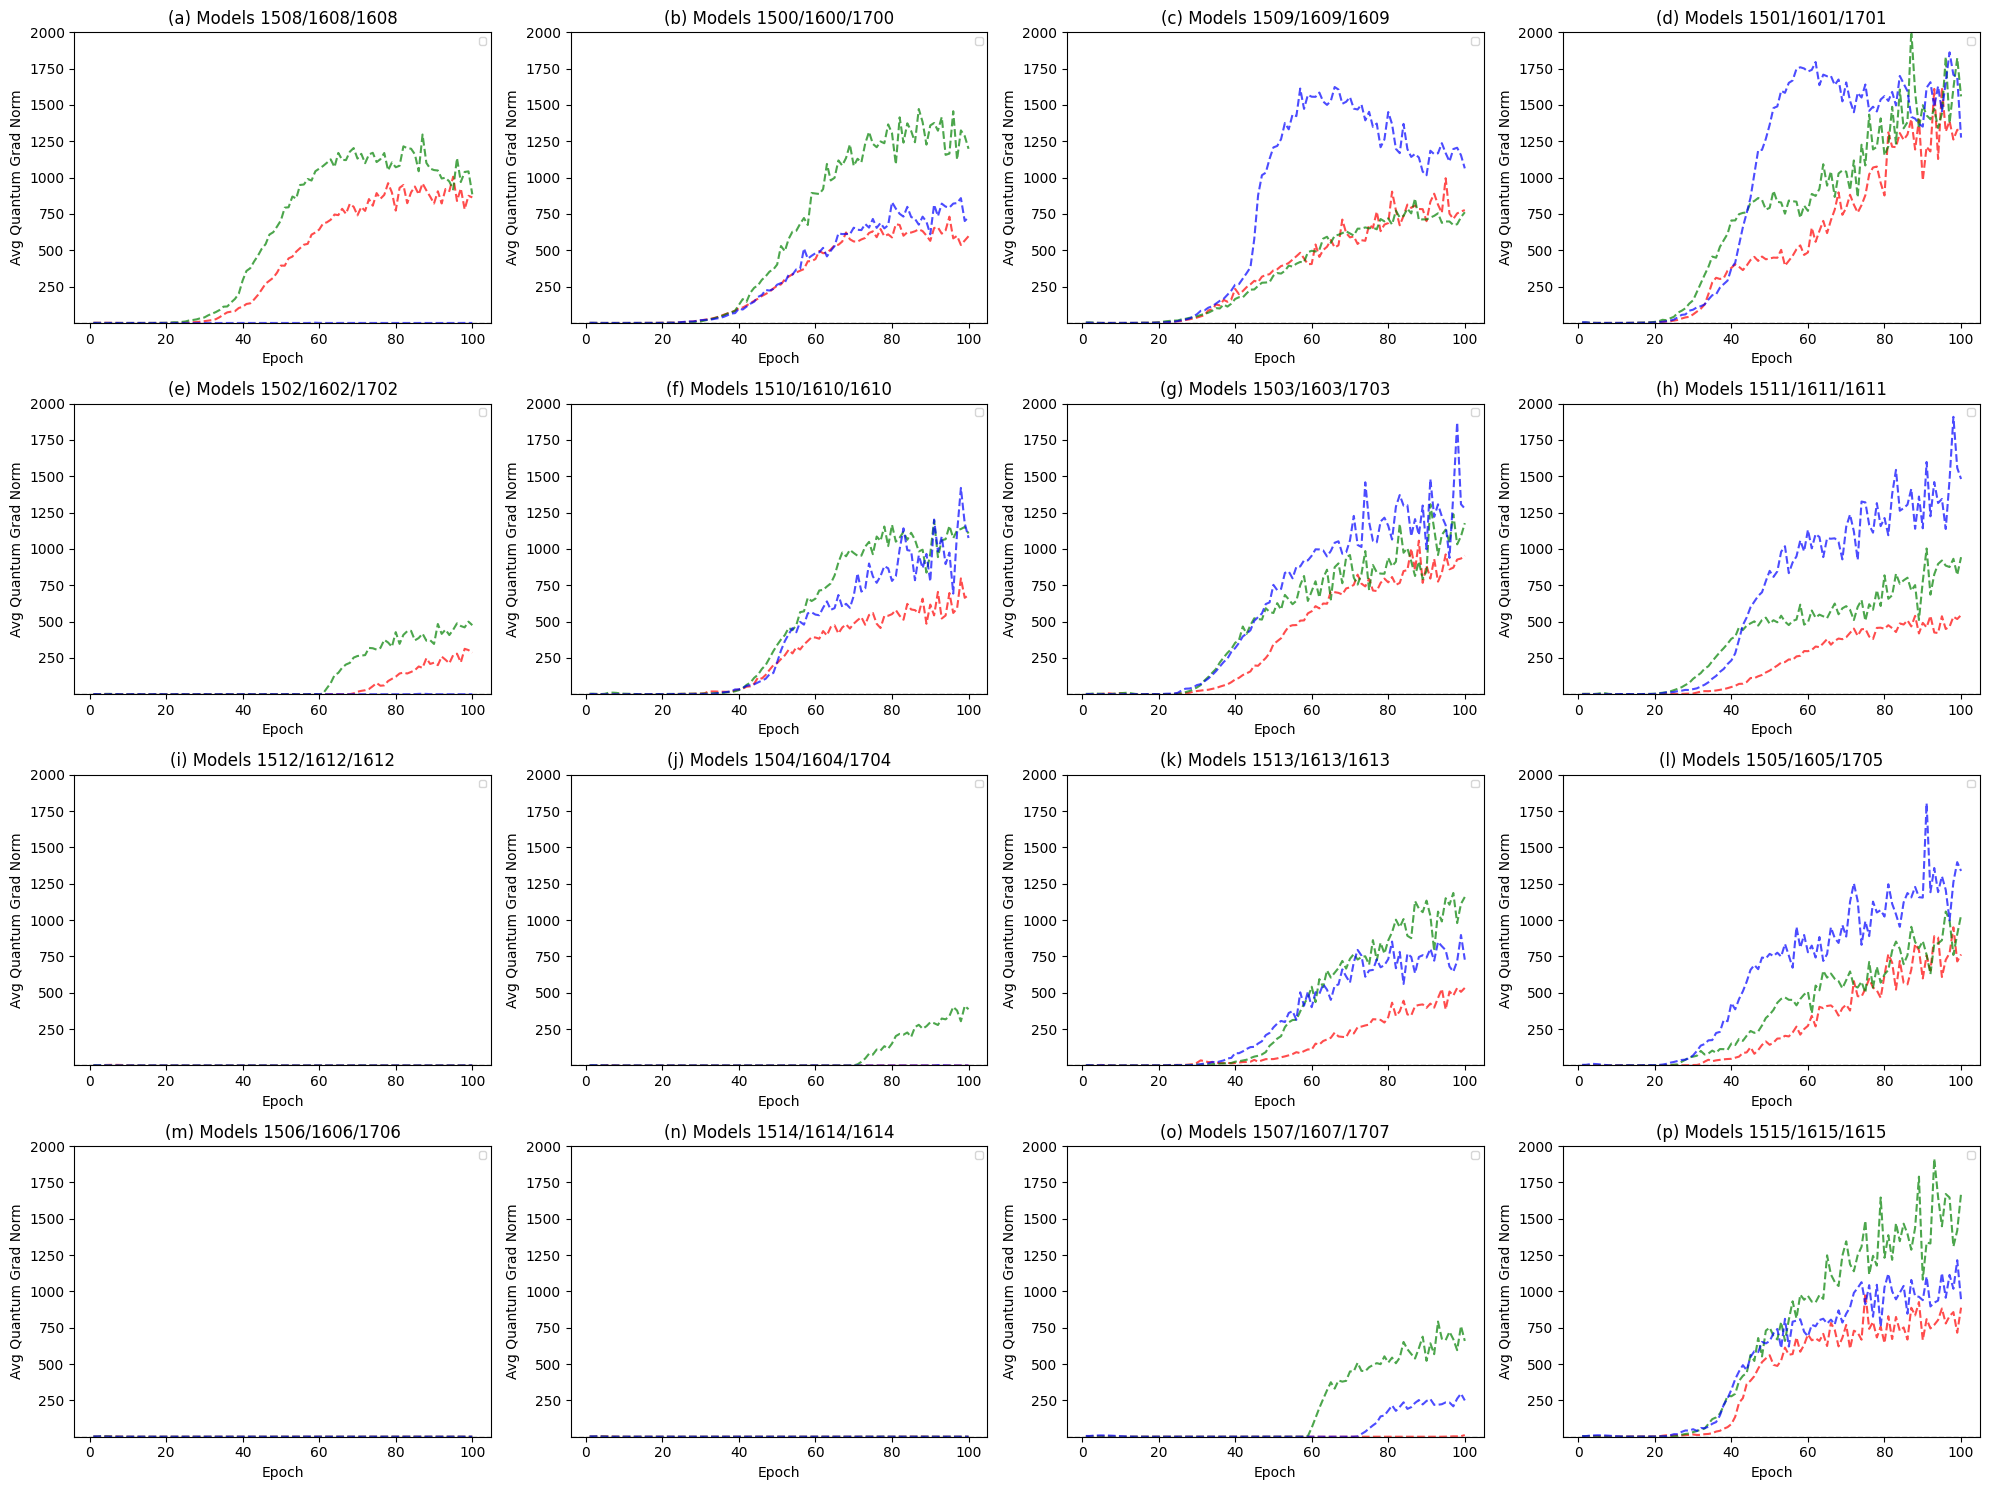

In [72]:
import matplotlib.pyplot as plt
import json
import numpy as np

def impute_nans_with_neighbors(arr):
    arr = np.array(arr, dtype=np.float64)
    n = len(arr)
    for i in range(n):
        if np.isnan(arr[i]):
            prev_idx, next_idx = i - 1, i + 1
            while prev_idx >= 0 and np.isnan(arr[prev_idx]): prev_idx -= 1
            while next_idx < n and np.isnan(arr[next_idx]): next_idx += 1
            prev_val = arr[prev_idx] if prev_idx >= 0 else np.nan
            next_val = arr[next_idx] if next_idx < n else np.nan
            if not np.isnan(prev_val) and not np.isnan(next_val):
                arr[i] = (prev_val + next_val) / 2
            elif not np.isnan(prev_val):
                arr[i] = prev_val
            elif not np.isnan(next_val):
                arr[i] = next_val
            else:
                arr[i] = 0
    return arr.tolist()

def extract_grads(data):
    grads, epochs = [], []
    for entry in data:
        quantum = [v for k, v in entry["gradient_norm_layerwise"].items() if "quantum_layer" in k]
        value = sum(quantum) / len(quantum) if quantum else 0
        grads.append(value if value != 0 else np.nan)
        epochs.append(entry["epoch"])
    return impute_nans_with_neighbors(grads), epochs

# Model numbers
model_nums1 = [1508, 1500, 1509, 1501,
               1502, 1510, 1503, 1511,
               1512, 1504, 1513, 1505,
               1506, 1514, 1507, 1515]
model_nums2 = [i + 100 for i in model_nums1]
model_nums3 = [1608, 1700, 1609, 1701,
               1702, 1610, 1703, 1611,
               1612, 1704, 1613, 1705,
               1706, 1614, 1707, 1615]

fig1, axes = plt.subplots(4, 4, figsize=(20, 15))
ymin, ymax = 1e-6, 2000

for idx in range(16):
    row, col = divmod(idx, 4)
    ax = axes[row][col]
    if idx >= len(model_nums1):
        ax.axis('off')
        continue

    model_num1 = model_nums1[idx]
    model_num2 = model_nums2[idx]
    model_num3 = model_nums3[idx]

    file_path1 = f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{model_num1}_42_logs.json'
    file_path2 = f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{model_num2}_52_logs.json'
    file_path3 = f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{model_num3}_62_logs.json'

    try:
        with open(file_path1) as f1, open(file_path2) as f2, open(file_path3) as f3:
            data1 = json.load(f1)
            data2 = json.load(f2)
            data3 = json.load(f3)

        grads1, epochs1 = extract_grads(data1)
        grads2, epochs2 = extract_grads(data2)
        grads3, epochs3 = extract_grads(data3)

        min_len = min(len(grads1), len(grads2), len(grads3))
        grads1, grads2, grads3 = grads1[:min_len], grads2[:min_len], grads3[:min_len]
        epochs = epochs1[:min_len]

        ax.plot(epochs, grads1,  linestyle='--', color='red', alpha=0.7)
        ax.plot(epochs, grads2,  linestyle='--', color='green', alpha=0.7)
        ax.plot(epochs, grads3,  linestyle='--', color='blue', alpha=0.7)

        subplot_label = string.ascii_lowercase[idx]
        ax.set_title(f'({subplot_label}) Models {model_num1}/{model_num2}/{model_num3}')

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Avg Quantum Grad Norm')
        #ax.set_yscale('log')
        ax.set_ylim(ymin, ymax)
        ax.axhline(y=1, color='gray', linestyle='--', linewidth=1)
        ax.legend(fontsize=7)

    except FileNotFoundError:
        ax.set_title(f"Missing model {model_num1} or {model_num2}")
        ax.axis('off')

plt.tight_layout()
fig1.savefig("nifty_qgrad_seedwise_normal.svg", dpi=600, bbox_inches='tight')
plt.show()


### Mean + std 

y axis scale = log

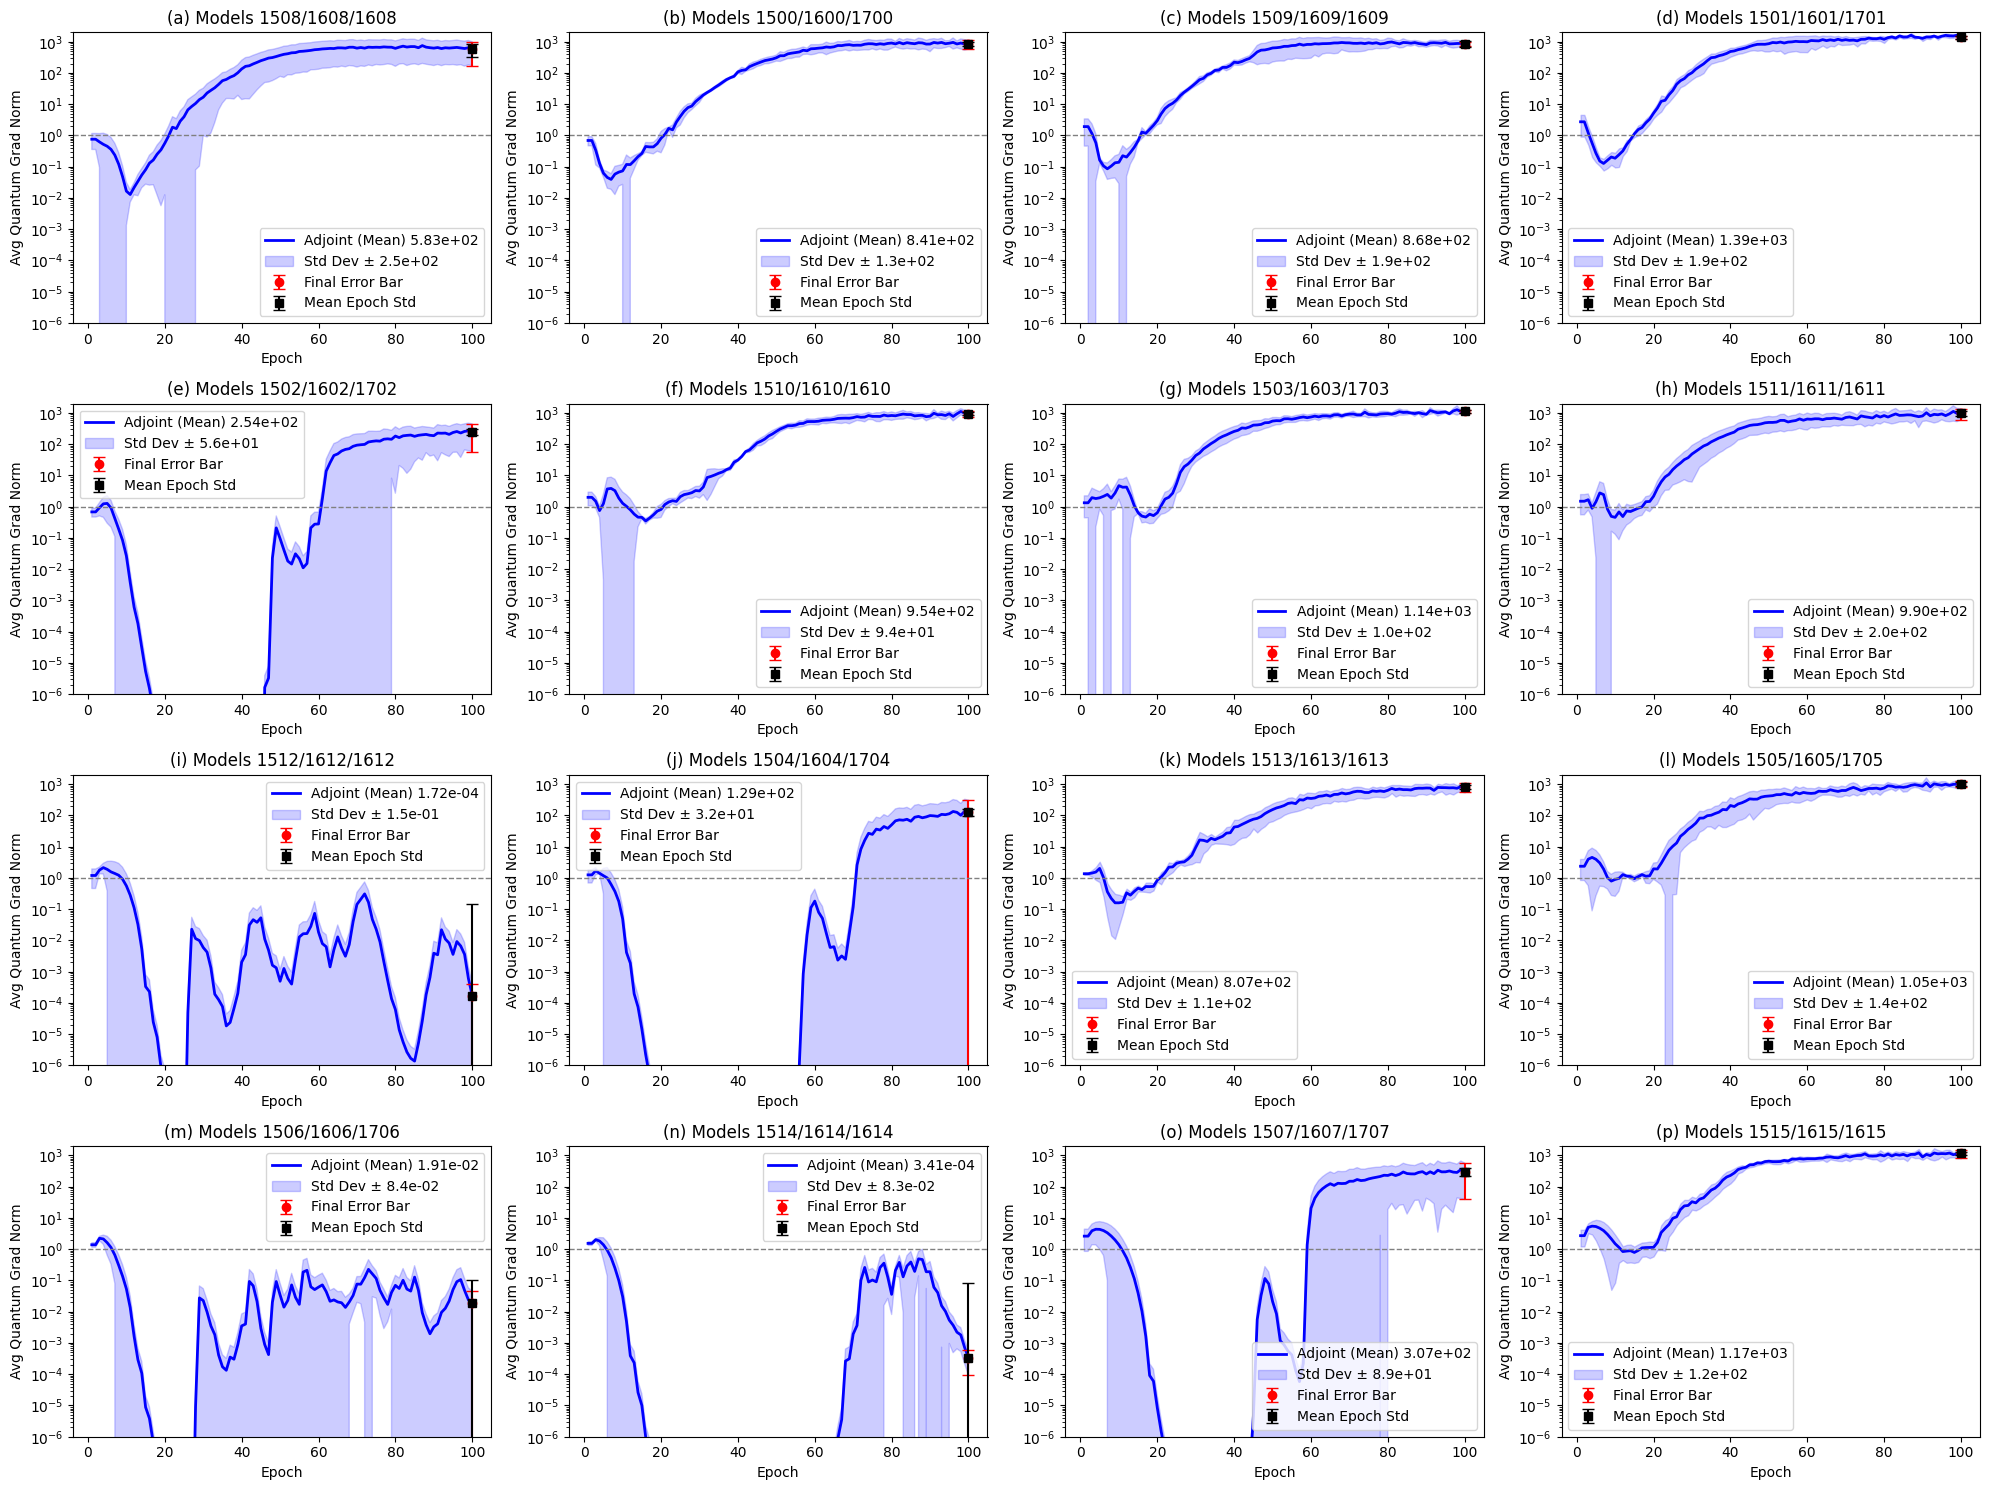

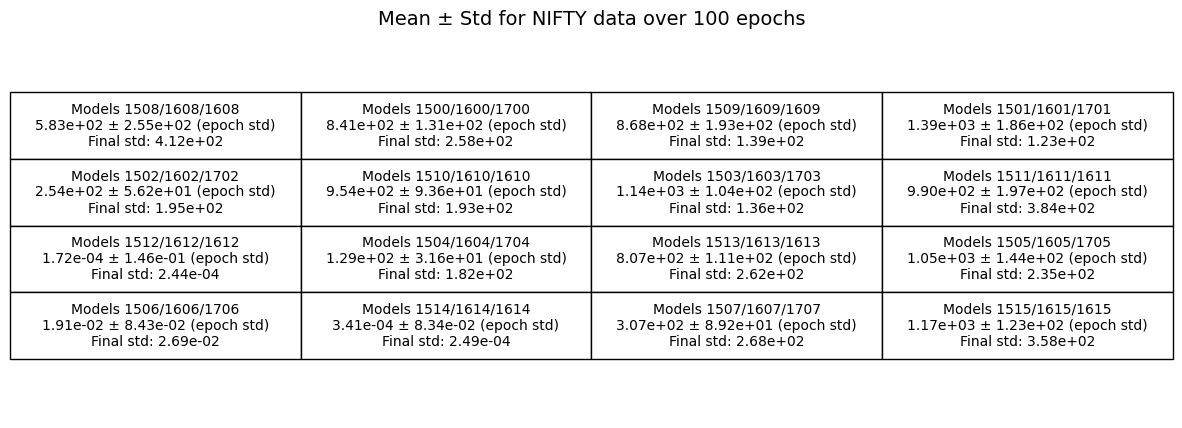

In [73]:
import matplotlib.pyplot as plt
import json
import numpy as np
import pandas as pd
import string  # For subplot labels

# Store the summary data
summary_data = []

def impute_nans_with_neighbors(arr):
    arr = np.array(arr, dtype=np.float64)
    n = len(arr)
    for i in range(n):
        if np.isnan(arr[i]):
            prev_idx = i - 1
            next_idx = i + 1
            while prev_idx >= 0 and np.isnan(arr[prev_idx]):
                prev_idx -= 1
            while next_idx < n and np.isnan(arr[next_idx]):
                next_idx += 1
            prev_val = arr[prev_idx] if prev_idx >= 0 else np.nan
            next_val = arr[next_idx] if next_idx < n else np.nan
            if not np.isnan(prev_val) and not np.isnan(next_val):
                arr[i] = (prev_val + next_val) / 2
            elif not np.isnan(prev_val):
                arr[i] = prev_val
            elif not np.isnan(next_val):
                arr[i] = next_val
            else:
                arr[i] = 0
    return arr.tolist()

# Define model numbers
model_nums1 = [1508, 1500, 1509, 1501,
               1502, 1510, 1503, 1511,
               1512, 1504, 1513, 1505,
               1506, 1514, 1507, 1515]
model_nums2 = [i + 100 for i in model_nums1]
model_nums3 = [1608, 1700, 1609, 1701,
               1702, 1610, 1703, 1611,
               1612, 1704, 1613, 1705,
               1706, 1614, 1707, 1615]

# Plot settings
fig1, axes = plt.subplots(4, 4, figsize=(20, 15))
ymin, ymax = 1e-6, 2000

# Loop over all subplots
for idx in range(16):
    row, col = divmod(idx, 4)
    ax = axes[row][col]

    if idx >= len(model_nums1):
        ax.axis('off')
        continue

    plot_idx = idx
    model_num1 = model_nums1[plot_idx]
    model_num2 = model_nums2[plot_idx]
    model_num3 = model_nums3[plot_idx]

    file_path1 = f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{model_num1}_42_logs.json'
    file_path2 = f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{model_num2}_52_logs.json'
    file_path3 = f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{model_num3}_62_logs.json'

    # Calculate mean and std for each model
    try:
        with open(file_path1) as f1, open(file_path2) as f2, open(file_path3) as f3:
            data1 = json.load(f1)
            data2 = json.load(f2)
            data3 = json.load(f3)

        def extract_grads(data):
            grads, epochs = [], []
            for entry in data:
                quantum = [v for k, v in entry["gradient_norm_layerwise"].items() if "quantum_layer" in k]
                value = sum(quantum) / len(quantum) if quantum else 0
                grads.append(value if value != 0 else np.nan)
                epochs.append(entry["epoch"])
            return impute_nans_with_neighbors(grads), epochs

        grads1, _ = extract_grads(data1)
        grads2, _ = extract_grads(data2)
        grads3, _ = extract_grads(data3)

        min_len = min(len(grads1), len(grads2), len(grads3))
        adjoint_runs = np.array([
            grads1[:min_len],
            grads2[:min_len],
            grads3[:min_len]
        ])

        adjoint_mean = np.nanmean(adjoint_runs, axis=0)
        adjoint_std = np.nanstd(adjoint_runs, axis=0)

        final_mean = adjoint_mean[-1]
        final_std = adjoint_std[-1]
        epoch_avg_std = np.mean(adjoint_std)
        summary_data.append((final_mean, final_std, epoch_avg_std))

    except FileNotFoundError:
        summary_data.append(None)

    # Plot the gradients
    try:
        with open(file_path1) as f1, open(file_path2) as f2, open(file_path3) as f3:
            data1 = json.load(f1)
            data2 = json.load(f2)
            data3 = json.load(f3)

        grads1, epochs1 = extract_grads(data1)
        grads2, epochs2 = extract_grads(data2)
        grads3, epochs3 = extract_grads(data3)

        min_len = min(len(grads1), len(grads2), len(grads3))
        grads1 = grads1[:min_len]
        grads2 = grads2[:min_len]
        grads3 = grads3[:min_len]
        epochs = epochs1[:min_len]

        adjoint_runs = np.array([grads1, grads2, grads3])
        adjoint_mean = np.nanmean(adjoint_runs, axis=0)
        adjoint_std = np.nanstd(adjoint_runs, axis=0)

        ax.plot(epochs, adjoint_mean, label=f'Adjoint (Mean) {final_mean:.2e}', color='blue', linewidth=2)
        ax.fill_between(
            epochs,
            adjoint_mean - adjoint_std,
            adjoint_mean + adjoint_std,
            color='blue', alpha=0.2,
            label=f'Std Dev ± {epoch_avg_std:.1e}'
        )

        # Add final error bar
        ax.errorbar(
            epochs[-1], adjoint_mean[-1],
            yerr=adjoint_std[-1],
            fmt='o', color='red', capsize=4,
            label='Final Error Bar'
        )

        # 🟠 Error bar for overall average std
        ax.errorbar(
            epochs[-1], adjoint_mean[-1],
            yerr=epoch_avg_std,
            fmt='s', color='black', capsize=4,
            label='Mean Epoch Std'
        )

       

        subplot_label = string.ascii_lowercase[idx]
        ax.set_title(f'({subplot_label}) Models {model_num1}/{model_num2}/{model_num3}')

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Avg Quantum Grad Norm')
        ax.set_yscale('log')
        ax.set_ylim(ymin, ymax)
        ax.axhline(y=1, color='gray', linestyle='--', linewidth=1)
        ax.legend()

    except FileNotFoundError:
        ax.set_title(f"Missing model {model_num1} or {model_num2}")
        ax.axis('off')


plt.tight_layout()

# Convert to 4x4 grid and display
fig2, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

# Create summary table with model names
cell_text = []
for row in range(4):
    cell_row = []
    for col in range(4):
        idx = row * 4 + col
        val = summary_data[idx]
        if val is None:
            cell_row.append("Missing")
        else:
            model_num1 = model_nums1[idx]
            model_num2 = model_nums2[idx]
            model_num3 = model_nums3[idx]
            mean_val, std_val, epoch_avg_std = val
            cell_row.append(
                f"Models {model_num1}/{model_num2}/{model_num3}\n"
                f"{mean_val:.2e} ± {epoch_avg_std:.2e} (epoch std)\n"
                f"Final std: {std_val:.2e}"
            )
    cell_text.append(cell_row)

table = ax.table(cellText=cell_text, loc='center', cellLoc='center', colWidths=[0.25]*4)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5, 4)
ax.set_title("Mean ± Std for NIFTY data over 100 epochs", fontsize=14)

fig1.savefig("nifty_qgrad_meanstd_100epoch_log.svg", dpi=600, bbox_inches='tight')
fig2.savefig("nifty_qgrad_summary_table.svg", dpi=600, bbox_inches='tight')
plt.show()


y axis scale = normal

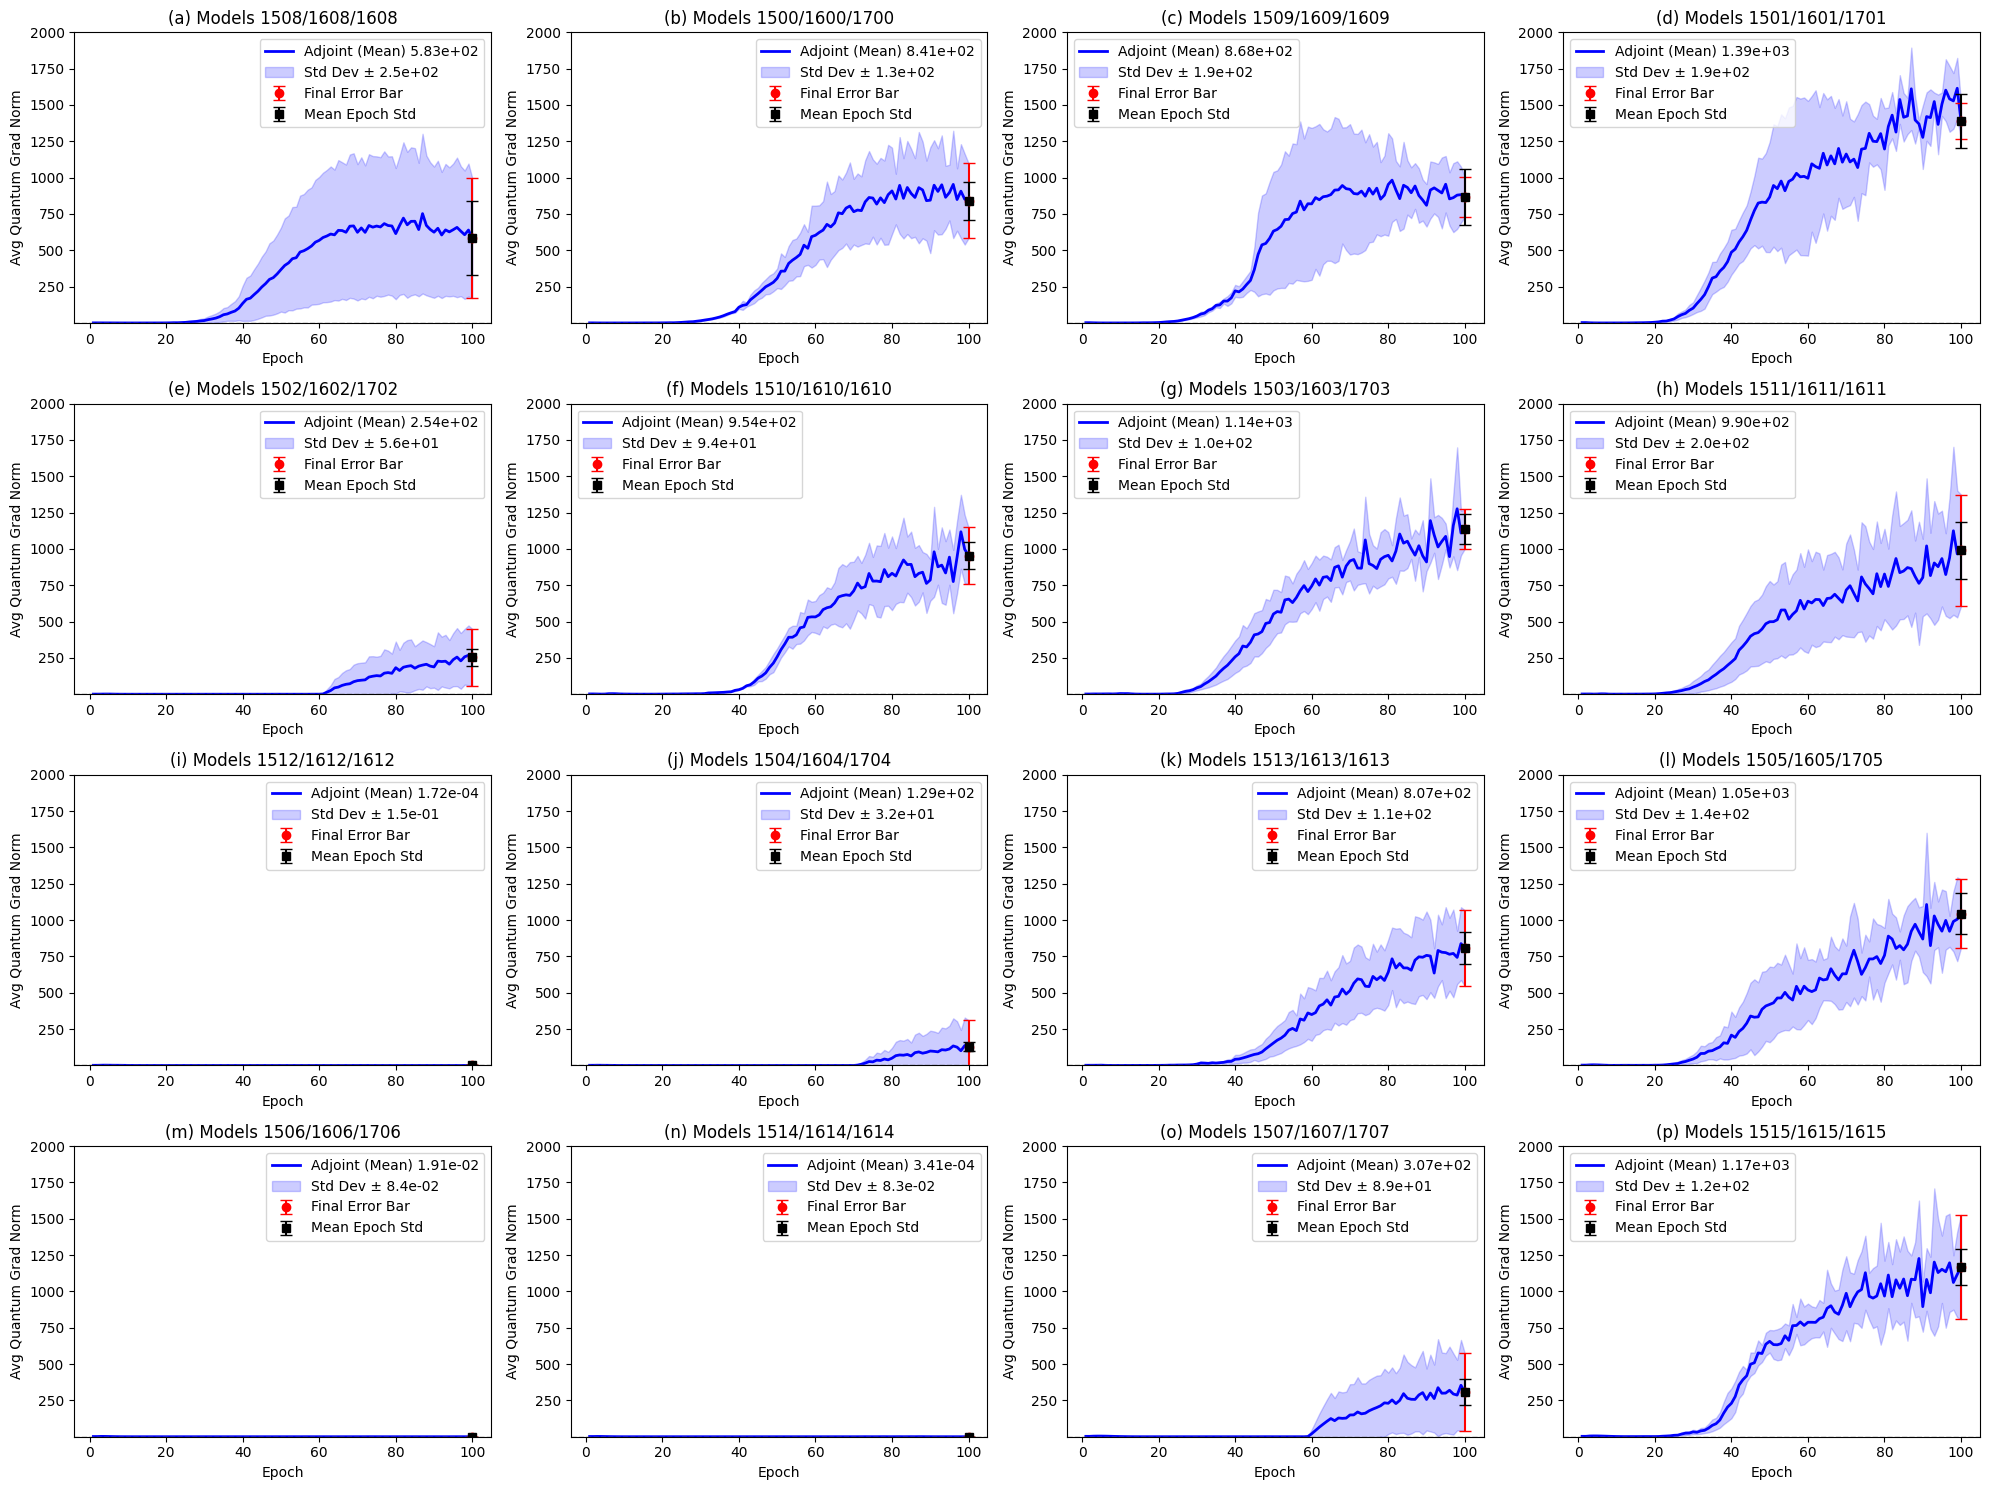

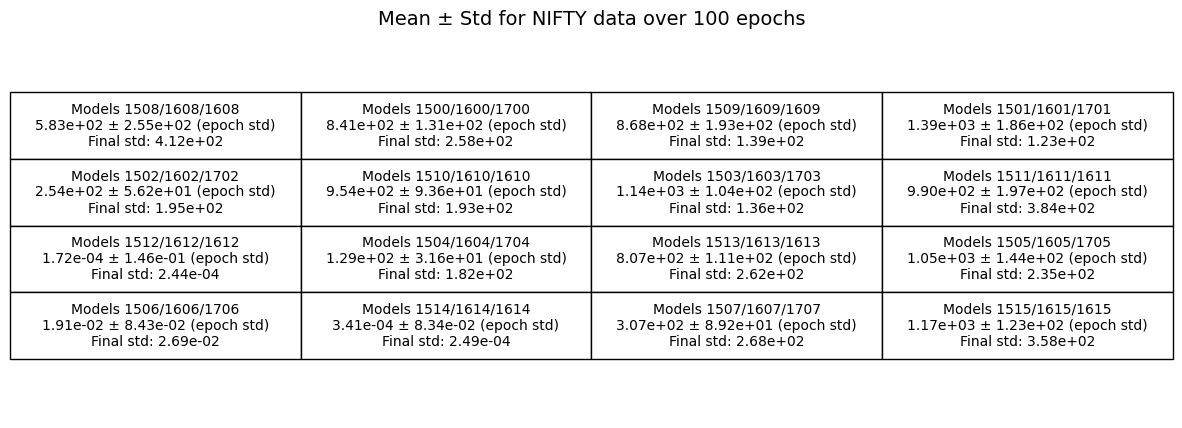

In [74]:
import matplotlib.pyplot as plt
import json
import numpy as np
import pandas as pd
import string  # for subplot labels

# Store the summary data
summary_data = []

def impute_nans_with_neighbors(arr):
    arr = np.array(arr, dtype=np.float64)
    n = len(arr)
    for i in range(n):
        if np.isnan(arr[i]):
            prev_idx = i - 1
            next_idx = i + 1
            while prev_idx >= 0 and np.isnan(arr[prev_idx]):
                prev_idx -= 1
            while next_idx < n and np.isnan(arr[next_idx]):
                next_idx += 1
            prev_val = arr[prev_idx] if prev_idx >= 0 else np.nan
            next_val = arr[next_idx] if next_idx < n else np.nan
            if not np.isnan(prev_val) and not np.isnan(next_val):
                arr[i] = (prev_val + next_val) / 2
            elif not np.isnan(prev_val):
                arr[i] = prev_val
            elif not np.isnan(next_val):
                arr[i] = next_val
            else:
                arr[i] = 0
    return arr.tolist()

# Define model numbers
model_nums1 = [1508, 1500, 1509, 1501,
               1502, 1510, 1503, 1511,
               1512, 1504, 1513, 1505,
               1506, 1514, 1507, 1515]
model_nums2 = [i + 100 for i in model_nums1]
model_nums3 = [1608, 1700, 1609, 1701,
               1702, 1610, 1703, 1611,
               1612, 1704, 1613, 1705,
               1706, 1614, 1707, 1615]

# Plot settings
fig1, axes = plt.subplots(4, 4, figsize=(20, 15))
ymin, ymax = 1e-6, 2000

# Loop over all subplots
for idx in range(16):
    row, col = divmod(idx, 4)
    ax = axes[row][col]

    if idx >= len(model_nums1):
        ax.axis('off')
        continue

    plot_idx = idx
    model_num1 = model_nums1[plot_idx]
    model_num2 = model_nums2[plot_idx]
    model_num3 = model_nums3[plot_idx]

    file_path1 = f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{model_num1}_42_logs.json'
    file_path2 = f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{model_num2}_52_logs.json'
    file_path3 = f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{model_num3}_62_logs.json'

    # Calculate mean and std for each model
    try:
        with open(file_path1) as f1, open(file_path2) as f2, open(file_path3) as f3:
            data1 = json.load(f1)
            data2 = json.load(f2)
            data3 = json.load(f3)

        def extract_grads(data):
            grads, epochs = [], []
            for entry in data:
                quantum = [v for k, v in entry["gradient_norm_layerwise"].items() if "quantum_layer" in k]
                value = sum(quantum) / len(quantum) if quantum else 0
                grads.append(value if value != 0 else np.nan)
                epochs.append(entry["epoch"])
            return impute_nans_with_neighbors(grads), epochs

        grads1, _ = extract_grads(data1)
        grads2, _ = extract_grads(data2)
        grads3, _ = extract_grads(data3)

        min_len = min(len(grads1), len(grads2), len(grads3))
        adjoint_runs = np.array([
            grads1[:min_len],
            grads2[:min_len],
            grads3[:min_len]
        ])

        adjoint_mean = np.nanmean(adjoint_runs, axis=0)
        adjoint_std = np.nanstd(adjoint_runs, axis=0)

        final_mean = adjoint_mean[-1]
        final_std = adjoint_std[-1]
        epoch_avg_std = np.mean(adjoint_std)
        summary_data.append((final_mean, final_std, epoch_avg_std))

    except FileNotFoundError:
        summary_data.append(None)

    # Plot the gradients
    try:
        with open(file_path1) as f1, open(file_path2) as f2, open(file_path3) as f3:
            data1 = json.load(f1)
            data2 = json.load(f2)
            data3 = json.load(f3)

        grads1, epochs1 = extract_grads(data1)
        grads2, epochs2 = extract_grads(data2)
        grads3, epochs3 = extract_grads(data3)

        min_len = min(len(grads1), len(grads2), len(grads3))
        grads1 = grads1[:min_len]
        grads2 = grads2[:min_len]
        grads3 = grads3[:min_len]
        epochs = epochs1[:min_len]

        adjoint_runs = np.array([grads1, grads2, grads3])
        adjoint_mean = np.nanmean(adjoint_runs, axis=0)
        adjoint_std = np.nanstd(adjoint_runs, axis=0)

        ax.plot(epochs, adjoint_mean, label=f'Adjoint (Mean) {final_mean:.2e}', color='blue', linewidth=2)
        ax.fill_between(
            epochs,
            adjoint_mean - adjoint_std,
            adjoint_mean + adjoint_std,
            color='blue', alpha=0.2,
            label=f'Std Dev ± {epoch_avg_std:.1e}'
        )

        # 🔴 Add final error bar
        ax.errorbar(
            epochs[-1], adjoint_mean[-1],
            yerr=adjoint_std[-1],
            fmt='o', color='red', capsize=4,
            label='Final Error Bar'
        )

        # 🟠 Error bar for overall average std
        ax.errorbar(
            epochs[-1], adjoint_mean[-1],
            yerr=epoch_avg_std,
            fmt='s', color='black', capsize=4,
            label='Mean Epoch Std'
        )

   

        subplot_label = string.ascii_lowercase[idx]
        ax.set_title(f'({subplot_label}) Models {model_num1}/{model_num2}/{model_num3}')

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Avg Quantum Grad Norm')
        #ax.set_yscale('log')
        ax.set_ylim(ymin, ymax)
        ax.axhline(y=1, color='gray', linestyle='--', linewidth=1)
        ax.legend()

    except FileNotFoundError:
        ax.set_title(f"Missing model {model_num1} or {model_num2}")
        ax.axis('off')

plt.tight_layout()

# Convert to 4x4 grid and display
fig2, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

# Create summary table with model names
cell_text = []
for row in range(4):
    cell_row = []
    for col in range(4):
        idx = row * 4 + col
        val = summary_data[idx]
        if val is None:
            cell_row.append("Missing")
        else:
            model_num1 = model_nums1[idx]
            model_num2 = model_nums2[idx]
            model_num3 = model_nums3[idx]
            mean_val, std_val, epoch_avg_std = val
            cell_row.append(
                f"Models {model_num1}/{model_num2}/{model_num3}\n"
                f"{mean_val:.2e} ± {epoch_avg_std:.2e} (epoch std)\n"
                f"Final std: {std_val:.2e}"
            )
    cell_text.append(cell_row)

table = ax.table(cellText=cell_text, loc='center', cellLoc='center', colWidths=[0.25]*4)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5, 4)
ax.set_title("Mean ± Std for NIFTY data over 100 epochs", fontsize=14)

fig1.savefig("nifty_qgrad_meanstd_100epoch_normal.svg", dpi=600, bbox_inches='tight')
#fig2.savefig("nifty_qgrad_summary_table.svg", dpi=600, bbox_inches='tight')
plt.show()


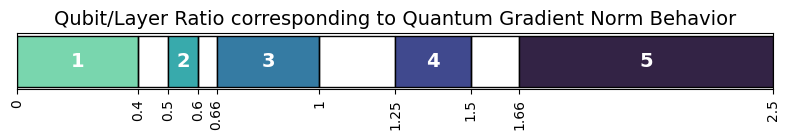

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Full range
min_val = 0
max_val = 2.5

# Define 8 thresholds (creates 9 regions)
thresholds = [0.4, 0.5, 0.6, 0.66, 1, 1.25, 1.5, 1.66]
zones = [min_val] + thresholds + [max_val]

# Get 5 shades from seaborn's 'mako' palette
mako_shades = sns.color_palette("mako", 5)[::-1]

# Assign colors to even zones, transparent to odd ones
zone_colors = []
color_idx = 0
for i in range(len(zones) - 1):
    if i % 2 == 0:
        zone_colors.append(mako_shades[color_idx])
        color_idx += 1
    else:
        zone_colors.append((1, 1, 1, 0))  # Transparent

# Plotting
fig, ax = plt.subplots(figsize=(8, 1.5))

for i in range(len(zones) - 1):
    left = zones[i]
    width = zones[i + 1] - zones[i]
    color = zone_colors[i]
    ax.barh(0, width, left=left, color=color, edgecolor='black')

    # Label only the colored zones
    if i % 2 == 0:
        label_num = i // 2 + 1
        ax.text(left + width / 2, 0, str(label_num),
                ha='center', va='center', fontsize=14, fontweight='bold', color='white')

# Axis setup
ax.set_xlim(min_val, max_val)
ax.set_yticks([])
ax.set_xticks(zones)
ax.set_xticklabels([str(round(z, 2)) for z in zones], rotation=90)
ax.set_title('Qubit/Layer Ratio corresponding to Quantum Gradient Norm Behavior', fontsize=14)

plt.tight_layout()
fig.savefig("qubit_layer_ratio_bar_mako_fixed.svg", dpi=600, bbox_inches='tight')
plt.show()


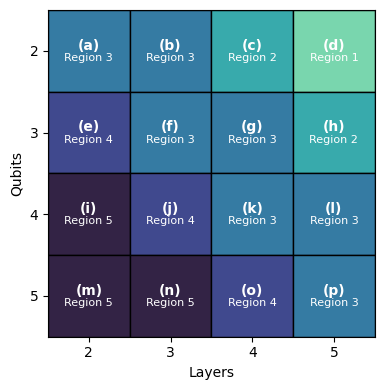

In [53]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
import string

# Get 5 distinct shades from Seaborn's 'mako' palette
colors = sns.color_palette("mako", 5)[::-1]

# Define the 5 zones with explicit coordinate assignments
zone_1 = {(2, 5)}
zone_2 = {(2, 4), (3, 5)}
zone_3 = {(2, 2), (2, 3), (3, 3), (3, 4), (4, 4), (4, 5), (5, 5)}
zone_4 = {(3, 2), (4, 3), (5, 4)}

x_vals = list(range(2, 6))
y_vals = list(range(2, 6))
all_coords = {(x, y) for x in x_vals for y in y_vals}
used_coords = zone_1 | zone_2 | zone_3 | zone_4
zone_5 = all_coords - used_coords

# Map coords to zone index (1-based)
zone_map = {}
for coord in zone_1: zone_map[coord] = 1
for coord in zone_2: zone_map[coord] = 2
for coord in zone_3: zone_map[coord] = 3
for coord in zone_4: zone_map[coord] = 4
for coord in zone_5: zone_map[coord] = 5

fig, ax = plt.subplots(figsize=(4, 4))

label_iter = iter(string.ascii_lowercase)  # For (a), (b), ...
for (y, x), zone in sorted(zone_map.items(), key=lambda item: (item[0][0], item[0][1])):
    color = colors[zone - 1]
    ax.add_patch(Rectangle((x - 0.5, y - 0.5), 1, 1, color=color, ec='black'))
    
    label = next(label_iter)
    # Draw label (a), (b), ...
    ax.text(x, y - 0.15, f"({label})", ha='center', va='top', fontsize=10, fontweight='bold', color='white')
    # Draw region number below label
    ax.text(x, y + 0.15, f"Region {zone}", ha='center', va='bottom', fontsize=8, color='white')


ax.set_xticks(x_vals)
ax.set_yticks(y_vals)
ax.set_xlim(1.5, 5.5)
ax.set_ylim(5.5, 1.5)  # top-left origin
ax.set_xlabel("Layers")
ax.set_ylabel("Qubits")
ax.set_aspect('equal')

plt.tight_layout()
fig.savefig("qubit_layer_ratio_grid_labeled_regions.svg", dpi=600, bbox_inches='tight')
plt.show()


## SYN DATA

### Seed wise

y axis scale = log

/tmp/ipykernel_8129/804863059.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


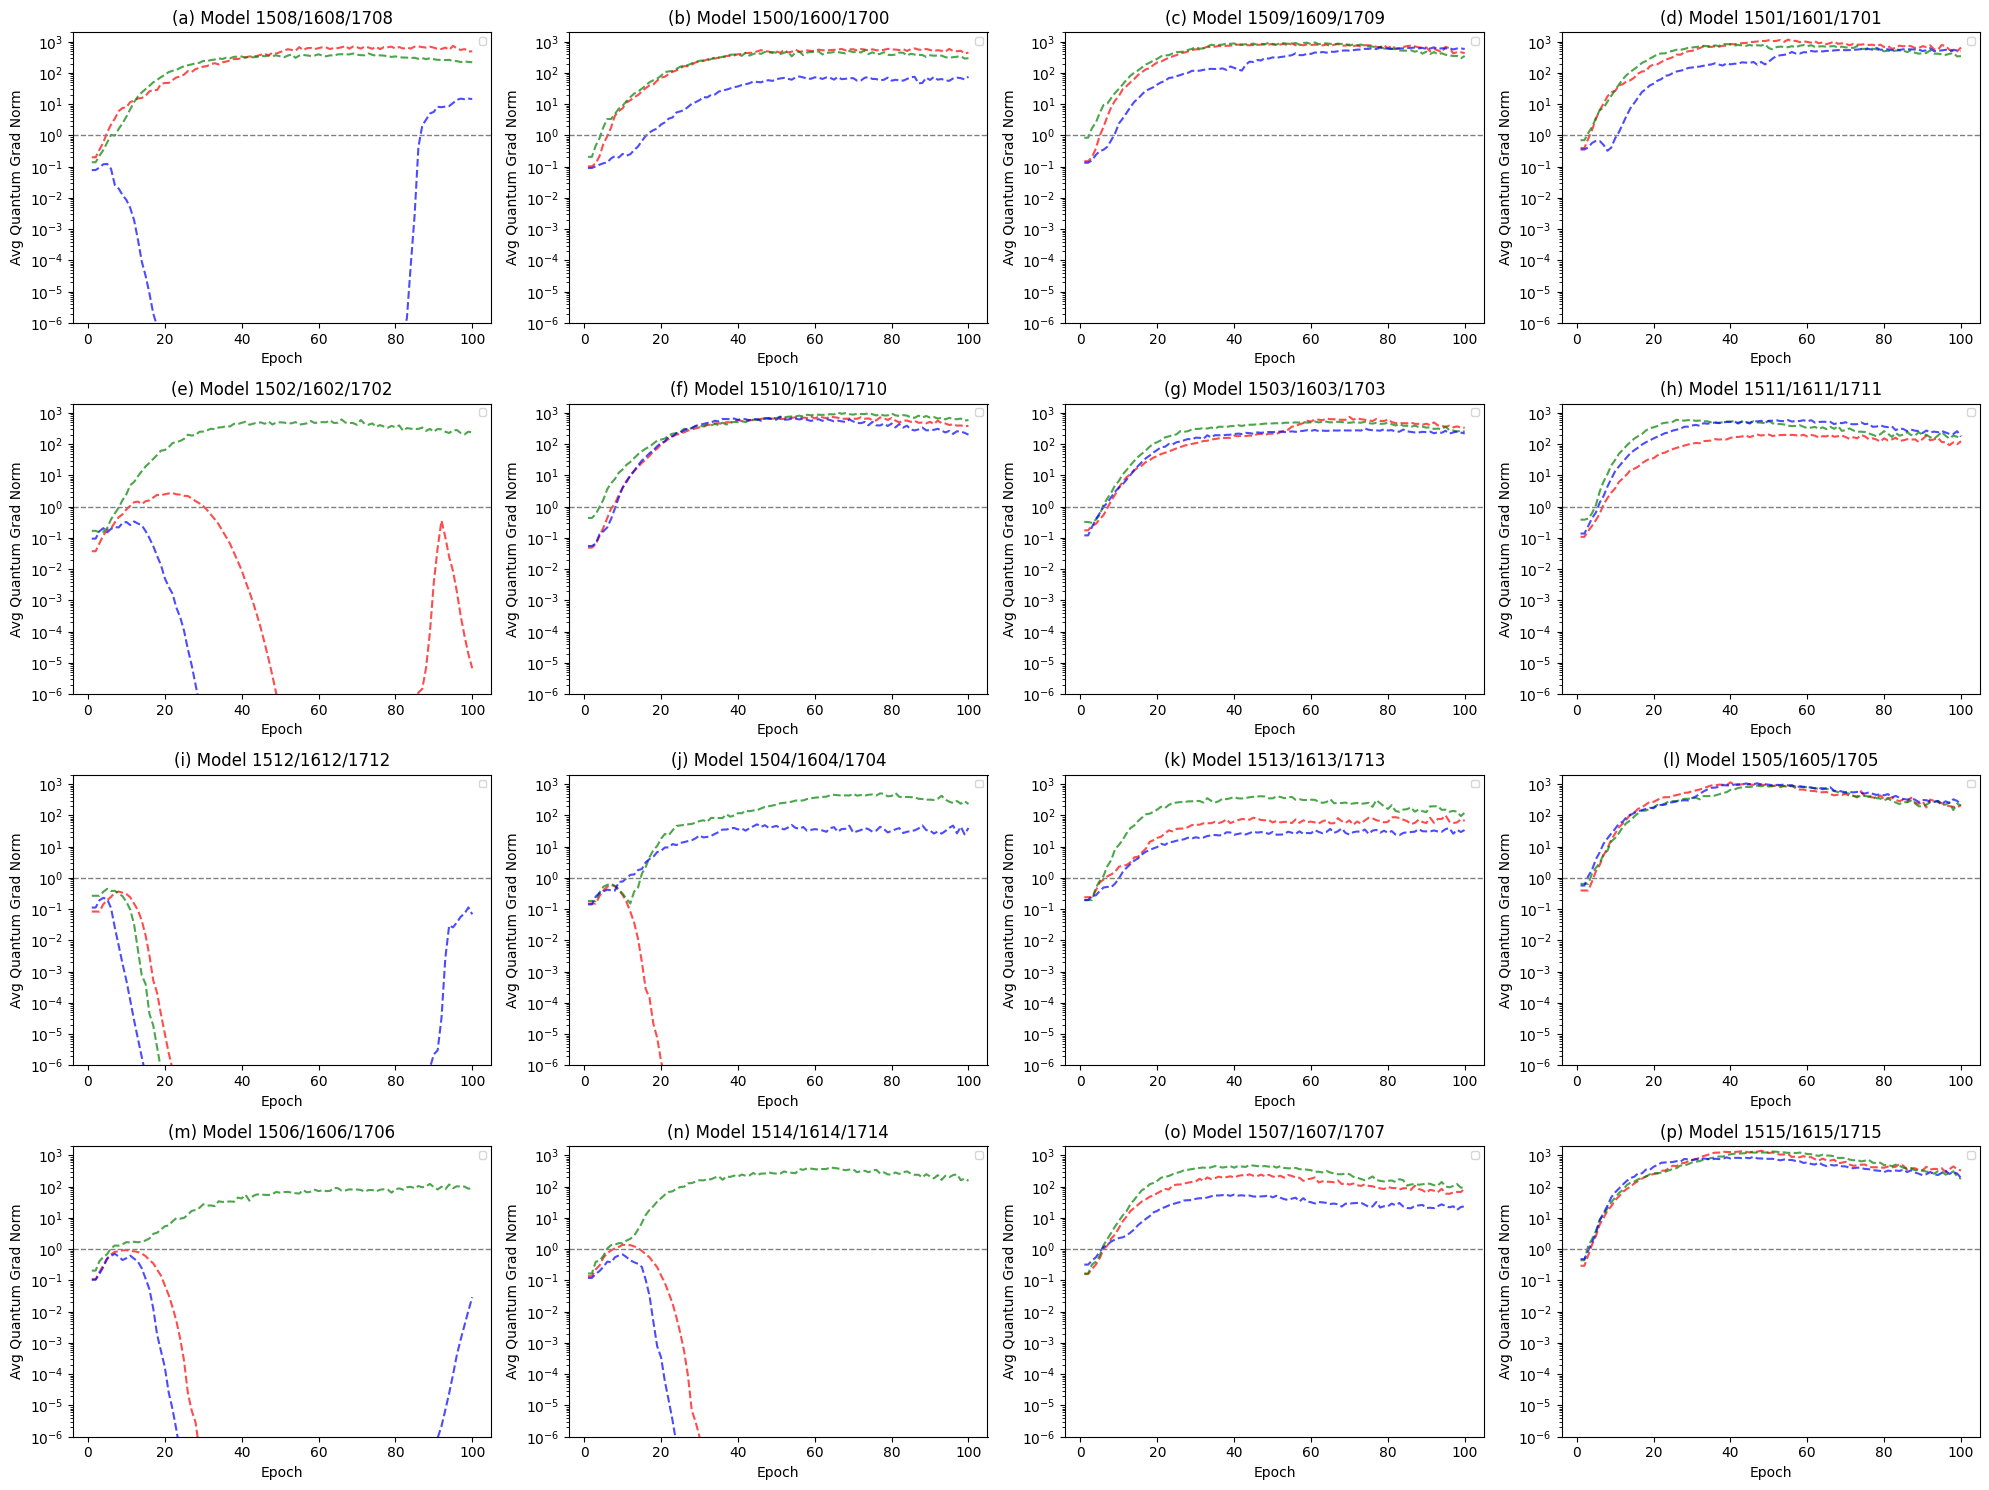

In [69]:
import matplotlib.pyplot as plt
import json
import numpy as np

def impute_nans_with_neighbors(arr):
    arr = np.array(arr, dtype=np.float64)
    n = len(arr)
    for i in range(n):
        if np.isnan(arr[i]):
            prev_idx, next_idx = i - 1, i + 1
            while prev_idx >= 0 and np.isnan(arr[prev_idx]): prev_idx -= 1
            while next_idx < n and np.isnan(arr[next_idx]): next_idx += 1
            prev_val = arr[prev_idx] if prev_idx >= 0 else np.nan
            next_val = arr[next_idx] if next_idx < n else np.nan
            if not np.isnan(prev_val) and not np.isnan(next_val):
                arr[i] = (prev_val + next_val) / 2
            elif not np.isnan(prev_val):
                arr[i] = prev_val
            elif not np.isnan(next_val):
                arr[i] = next_val
            else:
                arr[i] = 0
    return arr.tolist()

def extract_grads(data):
    grads, epochs = [], []
    for entry in data:
        quantum = [v for k, v in entry["gradient_norm_layerwise"].items() if "quantum_layer" in k]
        value = sum(quantum) / len(quantum) if quantum else 0
        grads.append(value if value != 0 else np.nan)
        epochs.append(entry["epoch"])
    return impute_nans_with_neighbors(grads), epochs

# Model numbers
model_nums1 = [1508, 1500, 1509, 1501,
               1502, 1510, 1503, 1511,
               1512, 1504, 1513, 1505,
               1506, 1514, 1507, 1515]
model_nums2 = [i + 100 for i in model_nums1]
model_nums3 = [i + 200 for i in model_nums1]

fig1, axes = plt.subplots(4, 4, figsize=(20, 15))
ymin, ymax = 1e-6, 2000

for idx in range(16):
    row, col = divmod(idx, 4)
    ax = axes[row][col]
    if idx >= len(model_nums1):
        ax.axis('off')
        continue

    model_num1 = model_nums1[idx]
    model_num2 = model_nums2[idx]
    model_num3 = model_nums3[idx]

    file_path1 = f'SYN/SYN_1000/logs/SYN_1000_{model_num1}_42_logs.json'
    file_path2 = f'SYN/SYN_1000/logs/SYN_1000_{model_num2}_52_logs.json'
    file_path3 = f'SYN/SYN_1000/logs/SYN_1000_{model_num3}_62_logs.json'

    try:
        with open(file_path1) as f1, open(file_path2) as f2, open(file_path3) as f3:
            data1 = json.load(f1)
            data2 = json.load(f2)
            data3 = json.load(f3)

        grads1, epochs1 = extract_grads(data1)
        grads2, epochs2 = extract_grads(data2)
        grads3, epochs3 = extract_grads(data3)

        min_len = min(len(grads1), len(grads2), len(grads3))
        grads1, grads2, grads3 = grads1[:min_len], grads2[:min_len], grads3[:min_len]
        epochs = epochs1[:min_len]

        ax.plot(epochs, grads1,  linestyle='--', color='red', alpha=0.7)
        ax.plot(epochs, grads2,  linestyle='--', color='green', alpha=0.7)
        ax.plot(epochs, grads3,  linestyle='--', color='blue', alpha=0.7)


        subplot_label = string.ascii_lowercase[idx]
        ax.set_title(f'({subplot_label}) Model {model_num1}/{model_num2}/{model_num3}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Avg Quantum Grad Norm')
        ax.set_yscale('log')
        ax.set_ylim(ymin, ymax)
        ax.axhline(y=1, color='gray', linestyle='--', linewidth=1)
        ax.legend(fontsize=7)

    except FileNotFoundError:
        ax.set_title(f"Missing model {model_num1} or {model_num2}")
        ax.axis('off')

plt.tight_layout()
fig1.savefig("syn_qgrad_seedwise_log.svg", dpi=600, bbox_inches='tight')
plt.show()


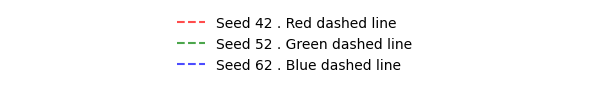

In [66]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 1))

# Create dummy lines with the same styles and labels
line1, = ax.plot([], [], linestyle='--', color='red', alpha=0.7, label=f'Seed 42 . Red dashed line')
line2, = ax.plot([], [], linestyle='--', color='green', alpha=0.7, label=f'Seed 52 . Green dashed line')
line3, = ax.plot([], [], linestyle='--', color='blue', alpha=0.7, label=f'Seed 62 . Blue dashed line')

# Only show legend
ax.legend(frameon=False, loc='center')
ax.axis('off')  # Hide axes

plt.tight_layout()
fig.savefig("seed_wise_label.svg", dpi=600, bbox_inches='tight')

plt.show()


y axis scale = normal

/tmp/ipykernel_8129/4276124842.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


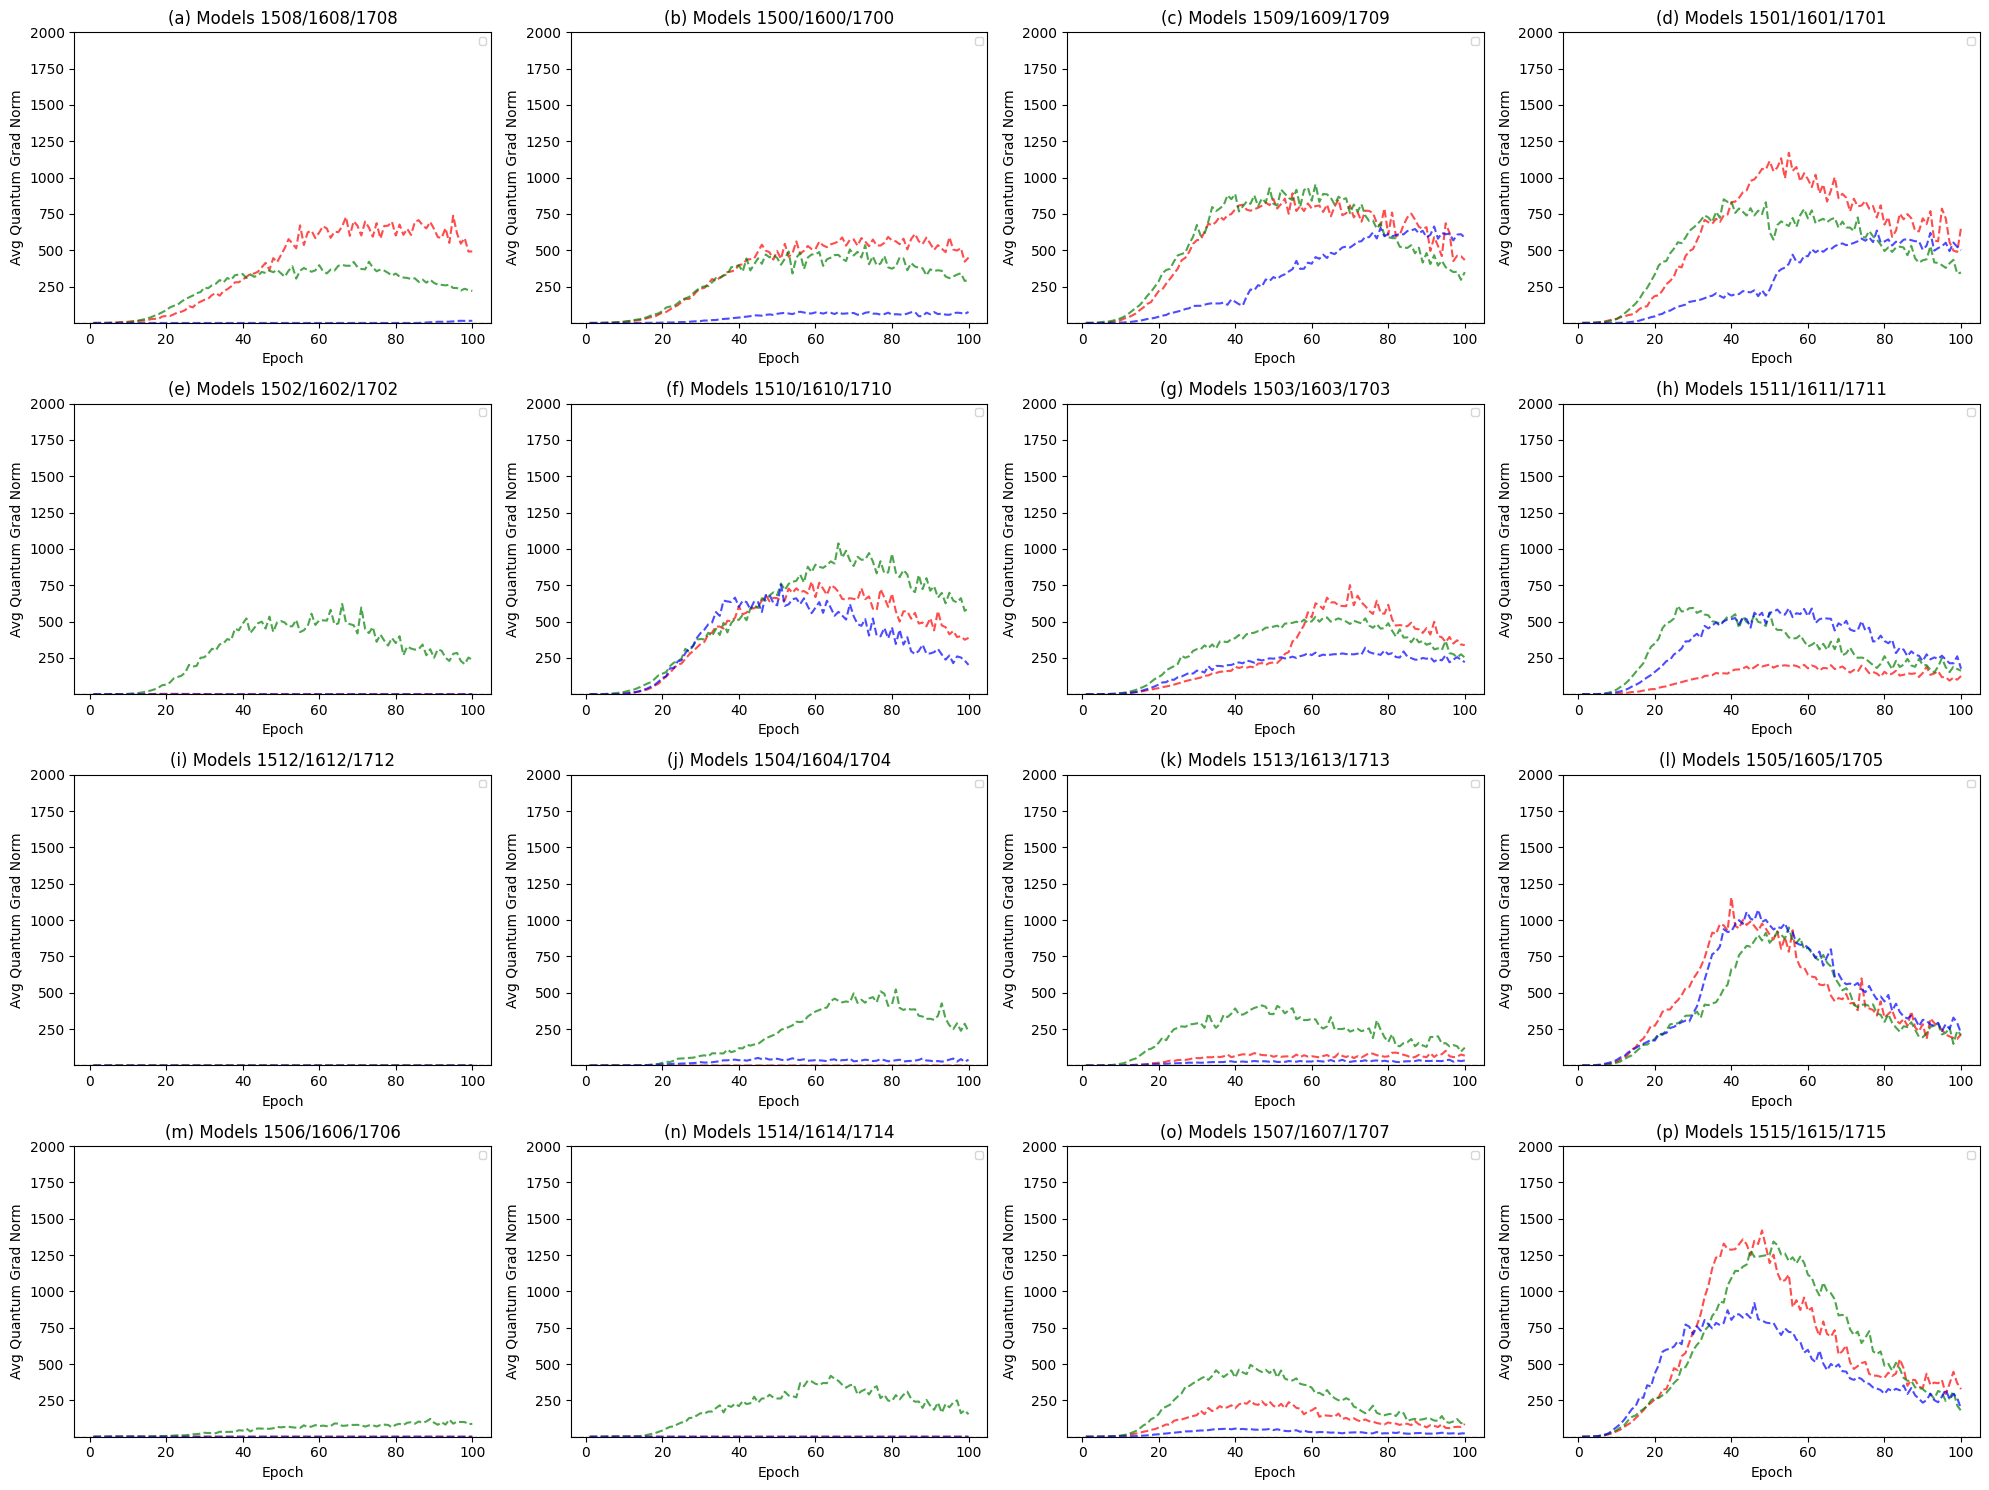

In [76]:
import matplotlib.pyplot as plt
import json
import numpy as np

def impute_nans_with_neighbors(arr):
    arr = np.array(arr, dtype=np.float64)
    n = len(arr)
    for i in range(n):
        if np.isnan(arr[i]):
            prev_idx, next_idx = i - 1, i + 1
            while prev_idx >= 0 and np.isnan(arr[prev_idx]): prev_idx -= 1
            while next_idx < n and np.isnan(arr[next_idx]): next_idx += 1
            prev_val = arr[prev_idx] if prev_idx >= 0 else np.nan
            next_val = arr[next_idx] if next_idx < n else np.nan
            if not np.isnan(prev_val) and not np.isnan(next_val):
                arr[i] = (prev_val + next_val) / 2
            elif not np.isnan(prev_val):
                arr[i] = prev_val
            elif not np.isnan(next_val):
                arr[i] = next_val
            else:
                arr[i] = 0
    return arr.tolist()

def extract_grads(data):
    grads, epochs = [], []
    for entry in data:
        quantum = [v for k, v in entry["gradient_norm_layerwise"].items() if "quantum_layer" in k]
        value = sum(quantum) / len(quantum) if quantum else 0
        grads.append(value if value != 0 else np.nan)
        epochs.append(entry["epoch"])
    return impute_nans_with_neighbors(grads), epochs

# Model numbers
model_nums1 = [1508, 1500, 1509, 1501,
               1502, 1510, 1503, 1511,
               1512, 1504, 1513, 1505,
               1506, 1514, 1507, 1515]
model_nums2 = [i + 100 for i in model_nums1]
model_nums3 = [i + 200 for i in model_nums1]

fig1, axes = plt.subplots(4, 4, figsize=(20, 15))
ymin, ymax = 1e-6, 2000

for idx in range(16):
    row, col = divmod(idx, 4)
    ax = axes[row][col]
    if idx >= len(model_nums1):
        ax.axis('off')
        continue

    model_num1 = model_nums1[idx]
    model_num2 = model_nums2[idx]
    model_num3 = model_nums3[idx]

    file_path1 = f'SYN/SYN_1000/logs/SYN_1000_{model_num1}_42_logs.json'
    file_path2 = f'SYN/SYN_1000/logs/SYN_1000_{model_num2}_52_logs.json'
    file_path3 = f'SYN/SYN_1000/logs/SYN_1000_{model_num3}_62_logs.json'

    try:
        with open(file_path1) as f1, open(file_path2) as f2, open(file_path3) as f3:
            data1 = json.load(f1)
            data2 = json.load(f2)
            data3 = json.load(f3)

        grads1, epochs1 = extract_grads(data1)
        grads2, epochs2 = extract_grads(data2)
        grads3, epochs3 = extract_grads(data3)

        min_len = min(len(grads1), len(grads2), len(grads3))
        grads1, grads2, grads3 = grads1[:min_len], grads2[:min_len], grads3[:min_len]
        epochs = epochs1[:min_len]

        ax.plot(epochs, grads1,  linestyle='--', color='red', alpha=0.7)
        ax.plot(epochs, grads2,  linestyle='--', color='green', alpha=0.7)
        ax.plot(epochs, grads3, linestyle='--', color='blue', alpha=0.7)

    

        subplot_label = string.ascii_lowercase[idx]
        ax.set_title(f'({subplot_label}) Models {model_num1}/{model_num2}/{model_num3}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Avg Quantum Grad Norm')
        #ax.set_yscale('log')
        ax.set_ylim(ymin, ymax)
        ax.axhline(y=1, color='gray', linestyle='--', linewidth=1)
        ax.legend(fontsize=7)

    except FileNotFoundError:
        ax.set_title(f"Missing model {model_num1} or {model_num2}")
        ax.axis('off')

plt.tight_layout()
fig1.savefig("syn_qgrad_seedwise_normal.svg", dpi=600, bbox_inches='tight')
plt.show()


### Mean + std

y axis scale = log

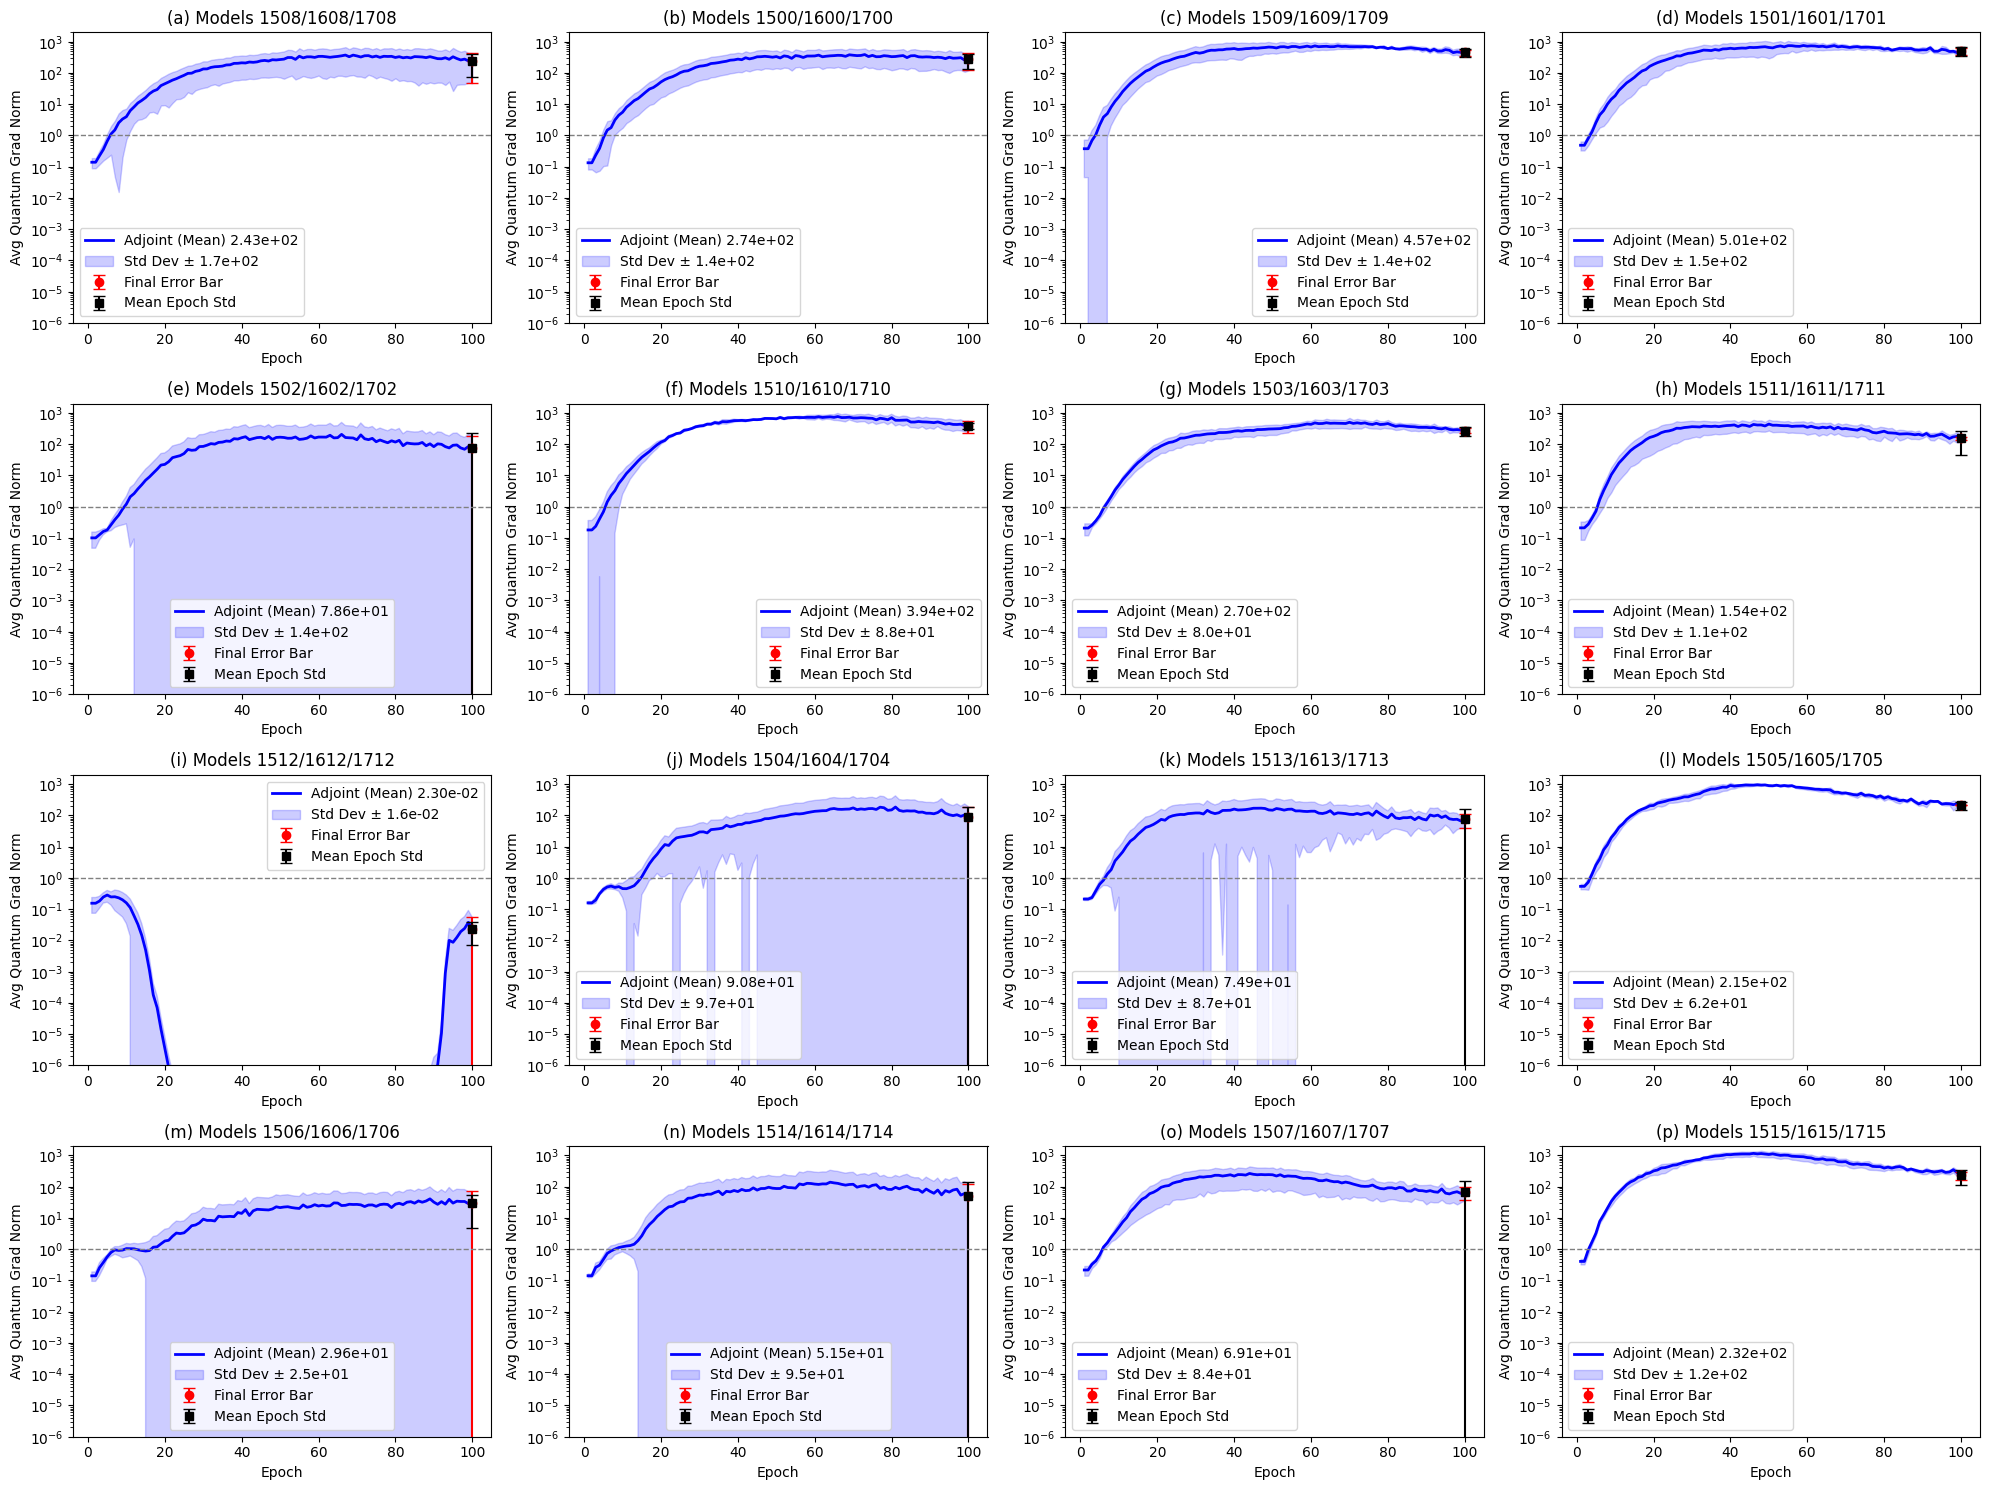

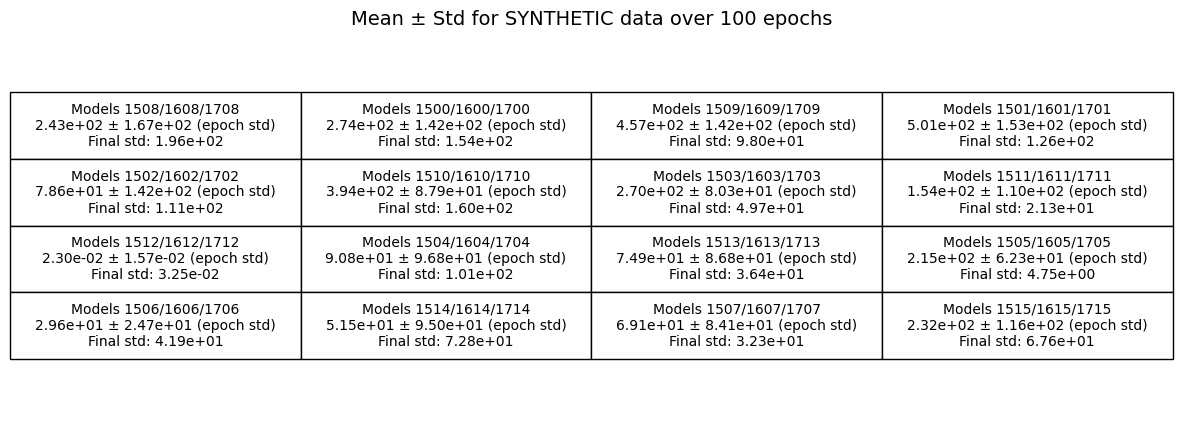

In [78]:
import matplotlib.pyplot as plt
import json
import numpy as np
import pandas as pd

# Store the summary data
summary_data = []


def impute_nans_with_neighbors(arr):
    arr = np.array(arr, dtype=np.float64)
    n = len(arr)
    for i in range(n):
        if np.isnan(arr[i]):
            prev_idx = i - 1
            next_idx = i + 1
            while prev_idx >= 0 and np.isnan(arr[prev_idx]):
                prev_idx -= 1
            while next_idx < n and np.isnan(arr[next_idx]):
                next_idx += 1
            prev_val = arr[prev_idx] if prev_idx >= 0 else np.nan
            next_val = arr[next_idx] if next_idx < n else np.nan
            if not np.isnan(prev_val) and not np.isnan(next_val):
                arr[i] = (prev_val + next_val) / 2
            elif not np.isnan(prev_val):
                arr[i] = prev_val
            elif not np.isnan(next_val):
                arr[i] = next_val
            else:
                arr[i] = 0
    return arr.tolist()

# Define model numbers
model_nums1 = [1508, 1500, 1509, 1501,
               1502, 1510, 1503, 1511,
               1512, 1504, 1513, 1505,
               1506, 1514, 1507, 1515]
model_nums2 = [i + 100 for i in model_nums1]
model_nums3 = [i + 200 for i in model_nums1]

# Plot settings
fig1, axes = plt.subplots(4, 4, figsize=(20, 15))
#ymin, ymax = 1e-6, 1e4
ymin, ymax = 1e-6, 2000

# Loop over all subplots
for idx in range(16):
    row, col = divmod(idx, 4)
    ax = axes[row][col]

    if idx >= len(model_nums1):
        ax.axis('off')
        continue

    plot_idx = idx
    model_num1 = model_nums1[plot_idx]
    model_num2 = model_nums2[plot_idx]
    model_num3 = model_nums3[plot_idx]

    file_path1 = f'SYN/SYN_1000/logs/SYN_1000_{model_num1}_42_logs.json'
    file_path2 = f'SYN/SYN_1000/logs/SYN_1000_{model_num2}_52_logs.json'
    file_path3 = f'SYN/SYN_1000/logs/SYN_1000_{model_num3}_62_logs.json'

    # Calculate mean and std for each model
    try:
        with open(file_path1) as f1, open(file_path2) as f2, open(file_path3) as f3:
            data1 = json.load(f1)
            data2 = json.load(f2)
            data3 = json.load(f3)

        grads1, _ = extract_grads(data1)
        grads2, _ = extract_grads(data2)
        grads3, _ = extract_grads(data3)

        min_len = min(len(grads1), len(grads2), len(grads3))
        adjoint_runs = np.array([
            grads1[:min_len],
            grads2[:min_len],
            grads3[:min_len]
        ])

        adjoint_mean = np.nanmean(adjoint_runs, axis=0)
        adjoint_std = np.nanstd(adjoint_runs, axis=0)

        final_mean = adjoint_mean[-1]
        final_std = adjoint_std[-1]
        epoch_avg_std = np.mean(adjoint_std)
        summary_data.append((final_mean, final_std, epoch_avg_std))

    except FileNotFoundError:
        summary_data.append(None)

    # Plot the gradients
    try:
        with open(file_path1) as f1, open(file_path2) as f2, open(file_path3) as f3:
            data1 = json.load(f1)
            data2 = json.load(f2)
            data3 = json.load(f3)

        def extract_grads(data):
            grads, epochs = [], []
            for entry in data:
                quantum = [v for k, v in entry["gradient_norm_layerwise"].items() if "quantum_layer" in k]
                value = sum(quantum) / len(quantum) if quantum else 0
                grads.append(value if value != 0 else np.nan)
                epochs.append(entry["epoch"])
            return impute_nans_with_neighbors(grads), epochs

        grads1, epochs1 = extract_grads(data1)
        grads2, epochs2 = extract_grads(data2)
        grads3, epochs3 = extract_grads(data3)

        min_len = min(len(grads1), len(grads2), len(grads3))
        grads1 = grads1[:min_len]
        grads2 = grads2[:min_len]
        grads3 = grads3[:min_len]
        epochs = epochs1[:min_len]

        adjoint_runs = np.array([grads1, grads2, grads3])
        adjoint_mean = np.nanmean(adjoint_runs, axis=0)
        adjoint_std = np.nanstd(adjoint_runs, axis=0)

        ax.plot(epochs, adjoint_mean, label=f'Adjoint (Mean) {final_mean:.2e}', color='blue', linewidth=2)
        ax.fill_between(
            epochs,
            adjoint_mean - adjoint_std,
            adjoint_mean + adjoint_std,
            color='blue', alpha=0.2,
            label=f'Std Dev ± {epoch_avg_std:.1e}'
        )

        # Add final error bar
        ax.errorbar(
            epochs[-1], adjoint_mean[-1],
            yerr=adjoint_std[-1],
            fmt='o', color='red', capsize=4,
            label='Final Error Bar'
        )

        # 🟠 Error bar for overall average std
        ax.errorbar(
            epochs[-1], adjoint_mean[-1],
            yerr=epoch_avg_std,
            fmt='s', color='black', capsize=4,
            label='Mean Epoch Std'
        )

 

        subplot_label = string.ascii_lowercase[idx]
        ax.set_title(f'({subplot_label}) Models {model_num1}/{model_num2}/{model_num3}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Avg Quantum Grad Norm')
        ax.set_yscale('log')
        ax.set_ylim(ymin, ymax)
        ax.axhline(y=1, color='gray', linestyle='--', linewidth=1)
        ax.legend()

    except FileNotFoundError:
        ax.set_title(f"Missing model {model_num1} or {model_num2}")
        ax.axis('off')

    
plt.tight_layout()


# Convert to 4x4 grid and display
fig2, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

# Create summary table with model names
cell_text = []
for row in range(4):
    cell_row = []
    for col in range(4):
        idx = row * 4 + col
        val = summary_data[idx]
        if val is None:
            cell_row.append("Missing")
        else:
            model_num1 = model_nums1[idx]
            model_num2 = model_nums2[idx]
            model_num3 = model_nums3[idx]
            mean_val, std_val, epoch_avg_std = val
            cell_row.append(
                f"Models {model_num1}/{model_num2}/{model_num3}\n"
                f"{mean_val:.2e} ± {epoch_avg_std:.2e} (epoch std)\n"
                f"Final std: {std_val:.2e}"
            )
    cell_text.append(cell_row)

table = ax.table(cellText=cell_text, loc='center', cellLoc='center', colWidths=[0.25]*4)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5, 4)
ax.set_title("Mean ± Std for SYNTHETIC data over 100 epochs", fontsize=14)


fig1.savefig("syn_qgrad_meanstd_100epoch_log.svg", dpi=600, bbox_inches='tight')
fig2.savefig("syn_qgrad_summary_table.svg", dpi=600, bbox_inches='tight')
plt.show()


y axis scale = normal

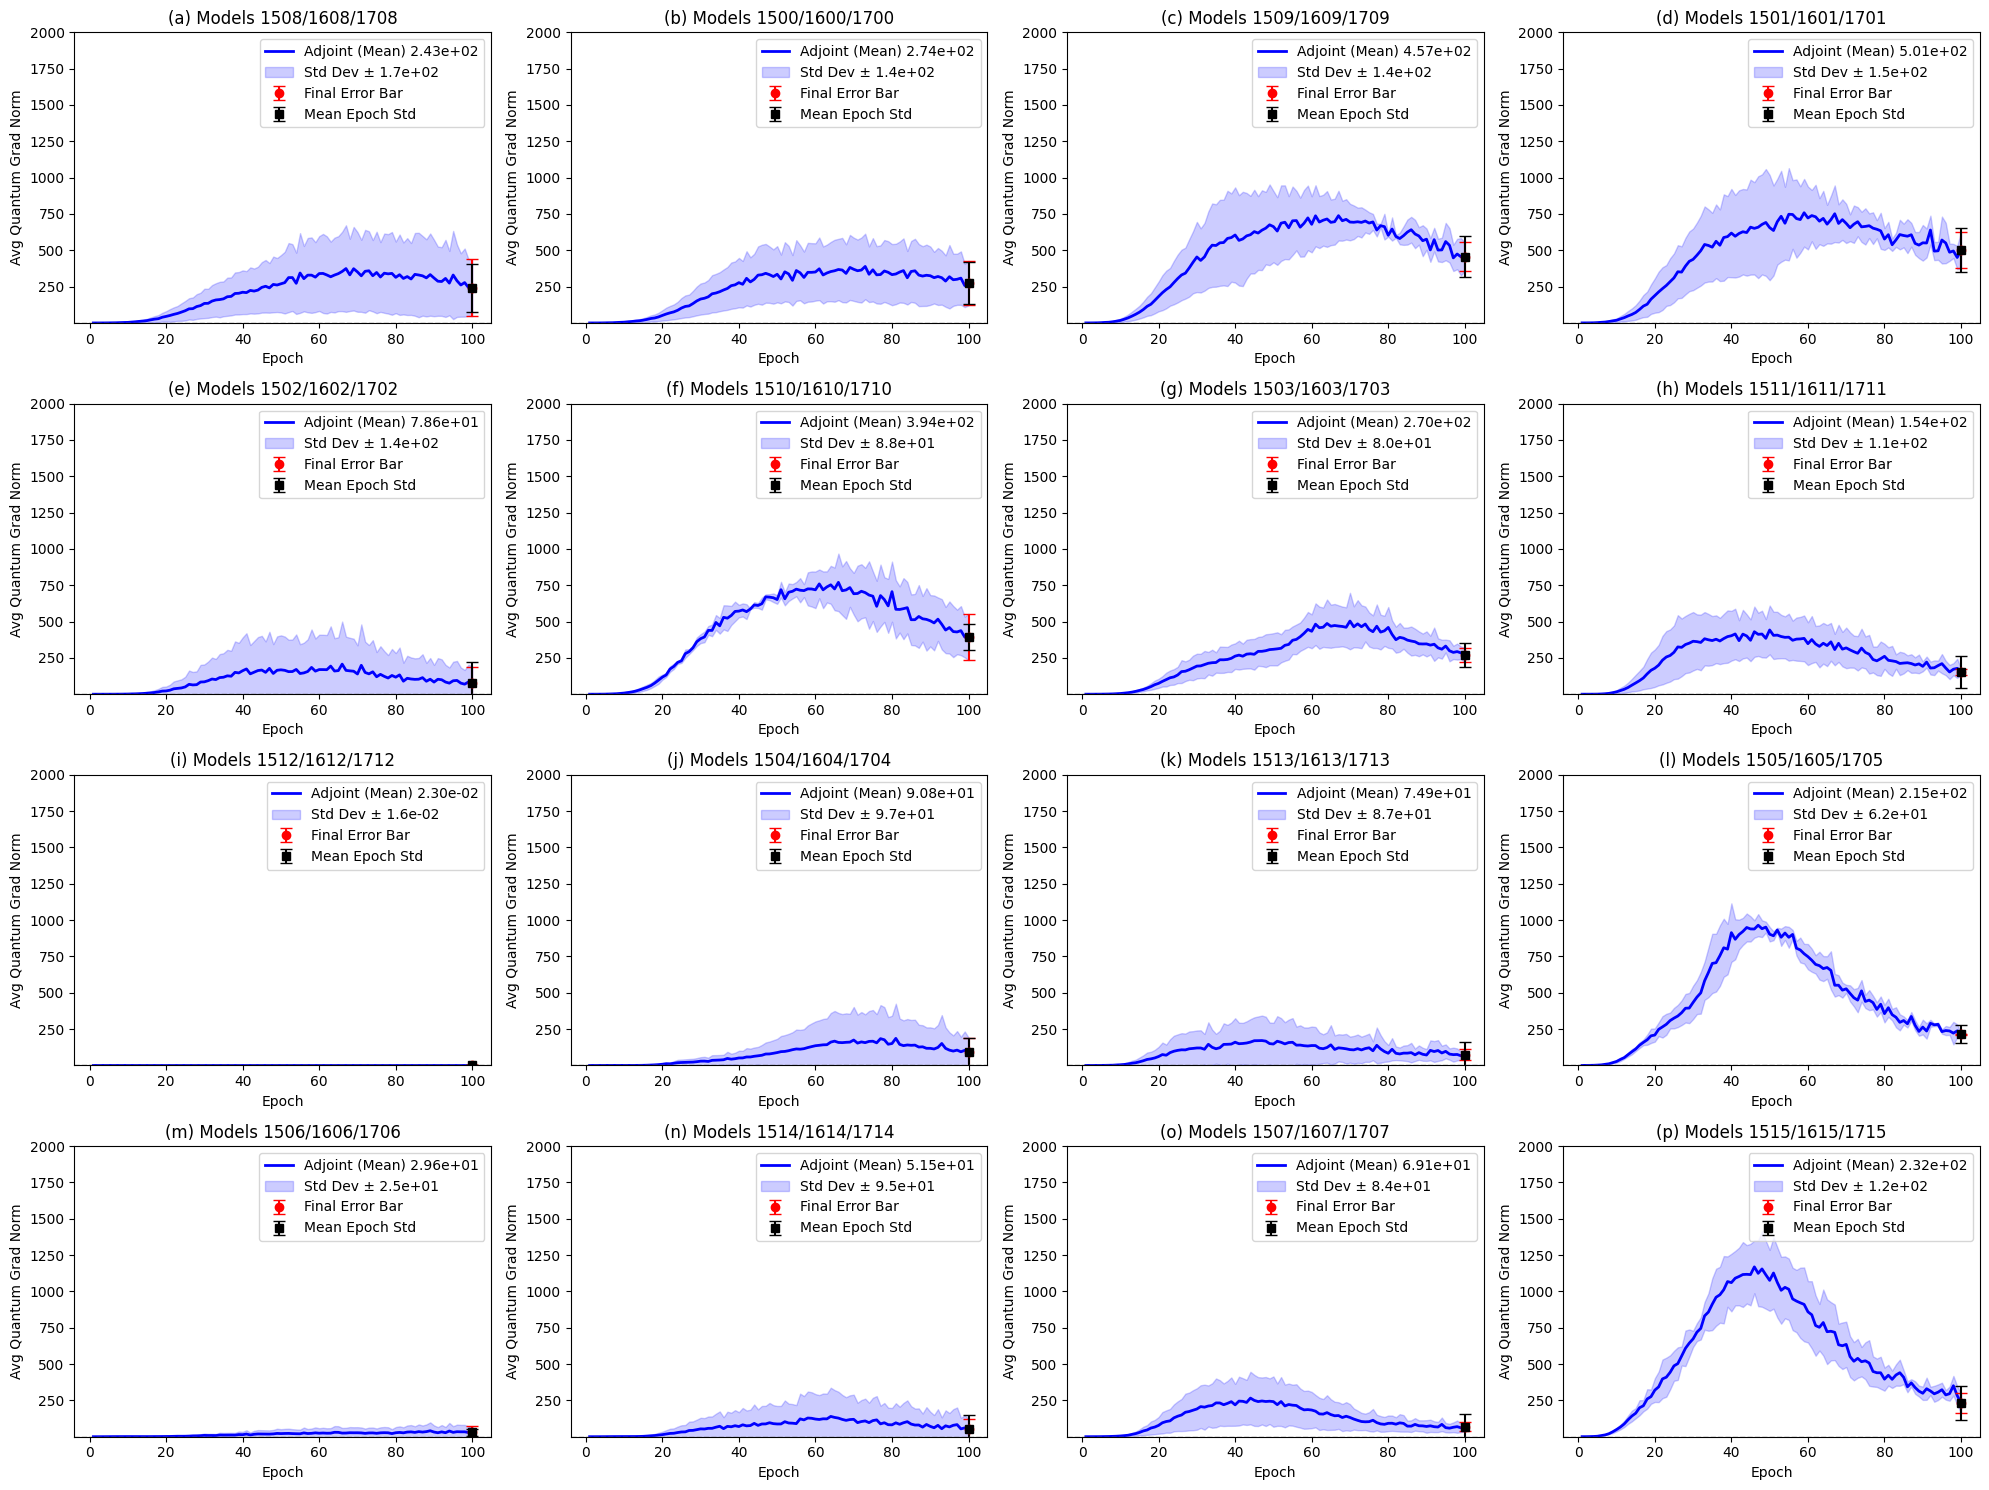

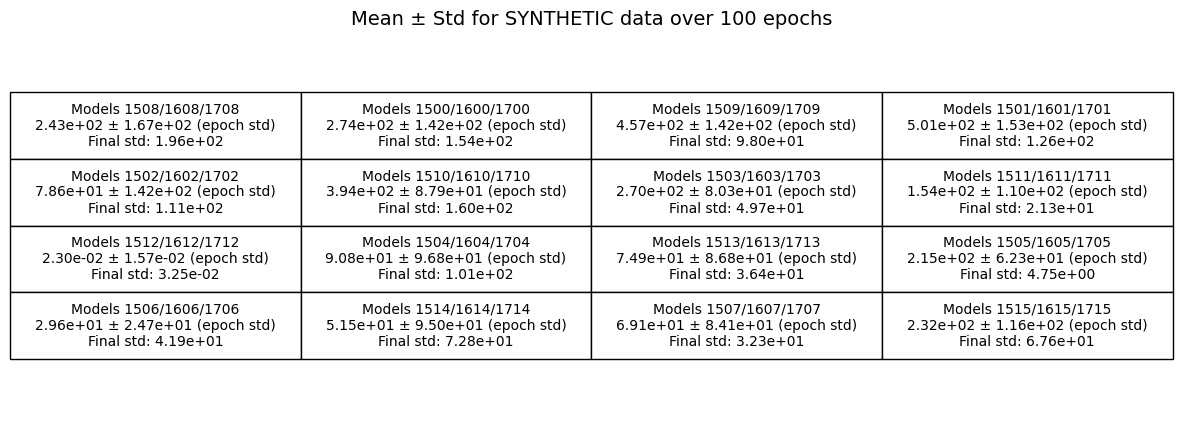

In [79]:
import matplotlib.pyplot as plt
import json
import numpy as np
import pandas as pd

# Store the summary data
summary_data = []


def impute_nans_with_neighbors(arr):
    arr = np.array(arr, dtype=np.float64)
    n = len(arr)
    for i in range(n):
        if np.isnan(arr[i]):
            prev_idx = i - 1
            next_idx = i + 1
            while prev_idx >= 0 and np.isnan(arr[prev_idx]):
                prev_idx -= 1
            while next_idx < n and np.isnan(arr[next_idx]):
                next_idx += 1
            prev_val = arr[prev_idx] if prev_idx >= 0 else np.nan
            next_val = arr[next_idx] if next_idx < n else np.nan
            if not np.isnan(prev_val) and not np.isnan(next_val):
                arr[i] = (prev_val + next_val) / 2
            elif not np.isnan(prev_val):
                arr[i] = prev_val
            elif not np.isnan(next_val):
                arr[i] = next_val
            else:
                arr[i] = 0
    return arr.tolist()

# Define model numbers
model_nums1 = [1508, 1500, 1509, 1501,
               1502, 1510, 1503, 1511,
               1512, 1504, 1513, 1505,
               1506, 1514, 1507, 1515]
model_nums2 = [i + 100 for i in model_nums1]
model_nums3 = [i + 200 for i in model_nums1]

# Plot settings
fig1, axes = plt.subplots(4, 4, figsize=(20, 15))
#ymin, ymax = 1e-6, 1e4
ymin, ymax = 1e-6, 2000

# Loop over all subplots
for idx in range(16):
    row, col = divmod(idx, 4)
    ax = axes[row][col]

    if idx >= len(model_nums1):
        ax.axis('off')
        continue

    plot_idx = idx
    model_num1 = model_nums1[plot_idx]
    model_num2 = model_nums2[plot_idx]
    model_num3 = model_nums3[plot_idx]

    file_path1 = f'SYN/SYN_1000/logs/SYN_1000_{model_num1}_42_logs.json'
    file_path2 = f'SYN/SYN_1000/logs/SYN_1000_{model_num2}_52_logs.json'
    file_path3 = f'SYN/SYN_1000/logs/SYN_1000_{model_num3}_62_logs.json'

    # Calculate mean and std for each model
    try:
        with open(file_path1) as f1, open(file_path2) as f2, open(file_path3) as f3:
            data1 = json.load(f1)
            data2 = json.load(f2)
            data3 = json.load(f3)

        grads1, _ = extract_grads(data1)
        grads2, _ = extract_grads(data2)
        grads3, _ = extract_grads(data3)

        min_len = min(len(grads1), len(grads2), len(grads3))
        adjoint_runs = np.array([
            grads1[:min_len],
            grads2[:min_len],
            grads3[:min_len]
        ])

        adjoint_mean = np.nanmean(adjoint_runs, axis=0)
        adjoint_std = np.nanstd(adjoint_runs, axis=0)

        final_mean = adjoint_mean[-1]
        final_std = adjoint_std[-1]
        epoch_avg_std = np.mean(adjoint_std)
        summary_data.append((final_mean, final_std, epoch_avg_std))

    except FileNotFoundError:
        summary_data.append(None)

    # Plot the gradients
    try:
        with open(file_path1) as f1, open(file_path2) as f2, open(file_path3) as f3:
            data1 = json.load(f1)
            data2 = json.load(f2)
            data3 = json.load(f3)

        def extract_grads(data):
            grads, epochs = [], []
            for entry in data:
                quantum = [v for k, v in entry["gradient_norm_layerwise"].items() if "quantum_layer" in k]
                value = sum(quantum) / len(quantum) if quantum else 0
                grads.append(value if value != 0 else np.nan)
                epochs.append(entry["epoch"])
            return impute_nans_with_neighbors(grads), epochs

        grads1, epochs1 = extract_grads(data1)
        grads2, epochs2 = extract_grads(data2)
        grads3, epochs3 = extract_grads(data3)

        min_len = min(len(grads1), len(grads2), len(grads3))
        grads1 = grads1[:min_len]
        grads2 = grads2[:min_len]
        grads3 = grads3[:min_len]
        epochs = epochs1[:min_len]

        adjoint_runs = np.array([grads1, grads2, grads3])
        adjoint_mean = np.nanmean(adjoint_runs, axis=0)
        adjoint_std = np.nanstd(adjoint_runs, axis=0)

        ax.plot(epochs, adjoint_mean, label=f'Adjoint (Mean) {final_mean:.2e}', color='blue', linewidth=2)
        ax.fill_between(
            epochs,
            adjoint_mean - adjoint_std,
            adjoint_mean + adjoint_std,
            color='blue', alpha=0.2,
            label=f'Std Dev ± {epoch_avg_std:.1e}'
        )

        # Add final error bar
        ax.errorbar(
            epochs[-1], adjoint_mean[-1],
            yerr=adjoint_std[-1],
            fmt='o', color='red', capsize=4,
            label='Final Error Bar'
        )

        # 🟠 Error bar for overall average std
        ax.errorbar(
            epochs[-1], adjoint_mean[-1],
            yerr=epoch_avg_std,
            fmt='s', color='black', capsize=4,
            label='Mean Epoch Std'
        )

        subplot_label = string.ascii_lowercase[idx]
        ax.set_title(f'({subplot_label}) Models {model_num1}/{model_num2}/{model_num3}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Avg Quantum Grad Norm')
        #ax.set_yscale('log')
        ax.set_ylim(ymin, ymax)
        ax.axhline(y=1, color='gray', linestyle='--', linewidth=1)
        ax.legend()

    except FileNotFoundError:
        ax.set_title(f"Missing model {model_num1} or {model_num2}")
        ax.axis('off')

    
plt.tight_layout()


# Convert to 4x4 grid and display
fig2, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

# Create summary table with model names
cell_text = []
for row in range(4):
    cell_row = []
    for col in range(4):
        idx = row * 4 + col
        val = summary_data[idx]
        if val is None:
            cell_row.append("Missing")
        else:
            model_num1 = model_nums1[idx]
            model_num2 = model_nums2[idx]
            model_num3 = model_nums3[idx]
            mean_val, std_val, epoch_avg_std = val
            cell_row.append(
                f"Models {model_num1}/{model_num2}/{model_num3}\n"
                f"{mean_val:.2e} ± {epoch_avg_std:.2e} (epoch std)\n"
                f"Final std: {std_val:.2e}"
            )
    cell_text.append(cell_row)

table = ax.table(cellText=cell_text, loc='center', cellLoc='center', colWidths=[0.25]*4)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5, 4)
ax.set_title("Mean ± Std for SYNTHETIC data over 100 epochs", fontsize=14)


fig1.savefig("syn_qgrad_meanstd_100epoch_normal.svg", dpi=600, bbox_inches='tight')
#fig2.savefig("syn_qgrad_summary_table.svg", dpi=600, bbox_inches='tight')
plt.show()


# Loss curve plots

## NIFTY DATA

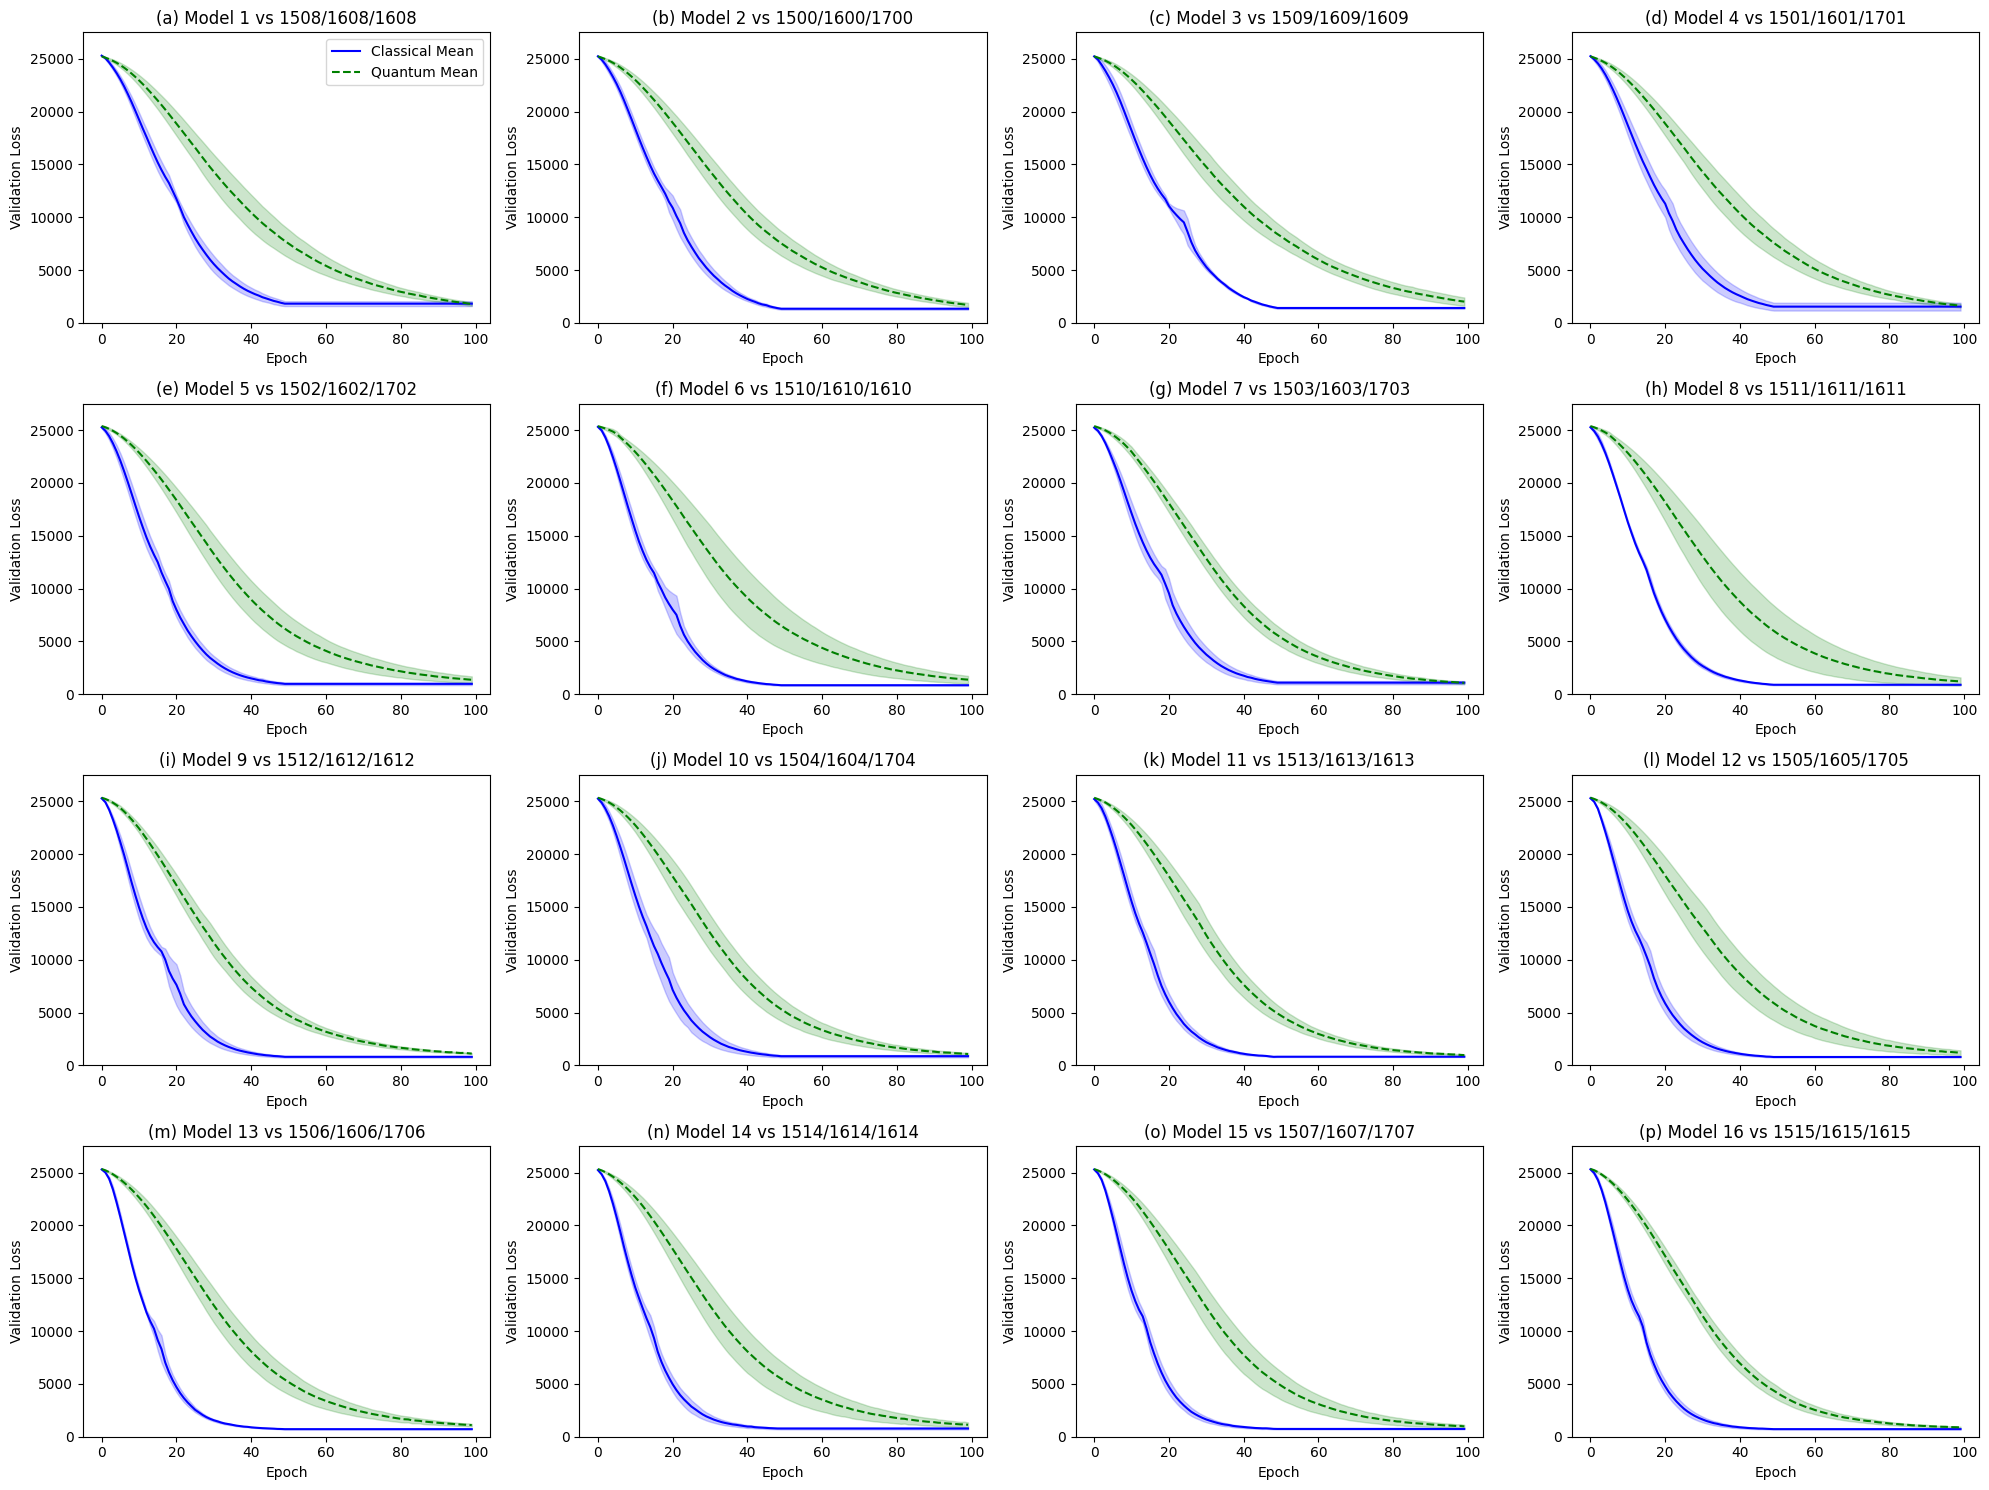

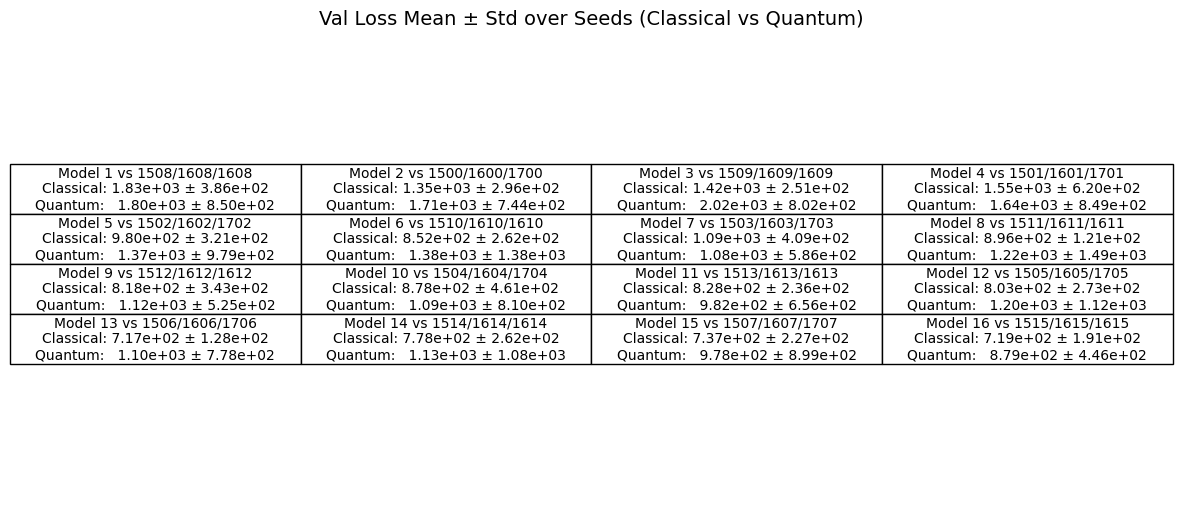

In [36]:
import matplotlib.pyplot as plt
import json
import numpy as np
import os
import string

def impute_nans_with_final_value(arr):
    arr = np.array(arr, dtype=np.float64)
    last_val = np.nan
    for i in range(len(arr)):
        if not np.isnan(arr[i]):
            last_val = arr[i]
        elif not np.isnan(last_val):
            arr[i] = last_val
    arr = np.nan_to_num(arr, nan=0.0)
    return arr.tolist()

def extract_losses(data):
    train, val, epochs = [], [], []
    for entry in data:
        train.append(entry.get("train_loss", np.nan))
        val.append(entry.get("val_loss", np.nan))
        epochs.append(entry.get("epoch"))
    return impute_nans_with_final_value(train), impute_nans_with_final_value(val), epochs

# Model numbers
model_nums0 = list(range(1, 17))
model_nums1 = [1508, 1500, 1509, 1501,
               1502, 1510, 1503, 1511,
               1512, 1504, 1513, 1505,
               1506, 1514, 1507, 1515]
model_nums2 = [i + 100 for i in model_nums1]
model_nums3 = [1608, 1700, 1609, 1701,
               1702, 1610, 1703, 1611,
               1612, 1704, 1613, 1705,
               1706, 1614, 1707, 1615]

summary_data = []
fig1, axes = plt.subplots(4, 4, figsize=(20, 15))
loss_ymin, loss_ymax = 0, 27500

for i in range(16):
    row, col = divmod(i, 4)
    ax = axes[row][col]

    model_numx = model_nums0[i]
    model_num1 = model_nums1[i]
    model_num2 = model_nums2[i]
    model_num3 = model_nums3[i]

    classical_paths = [f'ANN_NIFTY/ANN_NIFTY_1000/logs/ANN_NIFTY_1000_{model_numx}_{s}_logs.json' for s in [42, 52, 62]]
    quantum_paths = [f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{m}_{s}_logs.json' for m, s in zip([model_num1, model_num2, model_num3], [42, 52, 62])]

    classical_vals, quantum_vals = [], []
    try:
        for path in classical_paths:
            with open(path) as f:
                _, val, _ = extract_losses(json.load(f))
                classical_vals.append(val)

        for path in quantum_paths:
            with open(path) as f:
                _, val, _ = extract_losses(json.load(f))
                quantum_vals.append(val)

        min_len = 100
        def pad_or_truncate(seq, target_len):
            return seq[:target_len] if len(seq) >= target_len else seq + [seq[-1]] * (target_len - len(seq))

        classical_stack = np.array([pad_or_truncate(v, min_len) for v in classical_vals])
        quantum_stack = np.array([pad_or_truncate(v, min_len) for v in quantum_vals])
        epochs = list(range(min_len))

        c_mean, c_std = np.nanmean(classical_stack, axis=0), np.nanstd(classical_stack, axis=0)
        q_mean, q_std = np.nanmean(quantum_stack, axis=0), np.nanstd(quantum_stack, axis=0)

        summary_data.append({
            "model_nums": (model_numx, model_num1, model_num2, model_num3),
            "classical": (c_mean[-1], c_std[-1], np.mean(c_std)),
            "quantum": (q_mean[-1], q_std[-1], np.mean(q_std))
        })

        # Plot curves
        ax.plot(epochs, c_mean, label='Classical Mean', color='blue')
        ax.fill_between(epochs, c_mean - c_std, c_mean + c_std, color='blue', alpha=0.2)
        ax.plot(epochs, q_mean, label='Quantum Mean', color='green', linestyle='--')
        ax.fill_between(epochs, q_mean - q_std, q_mean + q_std, color='green', alpha=0.2)


        subplot_label = string.ascii_lowercase[i]
        ax.set_title(f'({subplot_label}) Model {model_numx} vs {model_num1}/{model_num2}/{model_num3}')


        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation Loss')
        ax.set_ylim(loss_ymin, loss_ymax)
        if i == 0:
            ax.legend()

    except FileNotFoundError as e:
        ax.set_title("Missing logs")
        ax.axis('off')
        print(f"Missing file: {e}")

fig1.tight_layout()
fig1.savefig("nifty_val_loss_comparison_curves_with_errorbars.svg", dpi=600, bbox_inches='tight')

# Create summary table
fig2, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
cell_text = []
for row in range(4):
    cell_row = []
    for col in range(4):
        idx = row * 4 + col
        if idx >= len(summary_data):
            cell_row.append("Missing")
            continue
        entry = summary_data[idx]
        c_mean, c_std, c_avg = entry["classical"]
        q_mean, q_std, q_avg = entry["quantum"]
        mx, m1, m2, m3 = entry["model_nums"]
        cell_row.append(
            f"Model {mx} vs {m1}/{m2}/{m3}\n"
            f"Classical: {c_mean:.2e} ± {c_avg:.2e}\n"
            f"Quantum:   {q_mean:.2e} ± {q_avg:.2e}"
        )
    cell_text.append(cell_row)

table = ax.table(cellText=cell_text, loc='center', cellLoc='center', colWidths=[0.25]*4)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.25, 3)
ax.set_title("Val Loss Mean ± Std over Seeds (Classical vs Quantum)", fontsize=14)
fig2.savefig("nifty_val_loss_comparison_summary_table.svg", dpi=600, bbox_inches='tight')
plt.show()


## SYN DATA

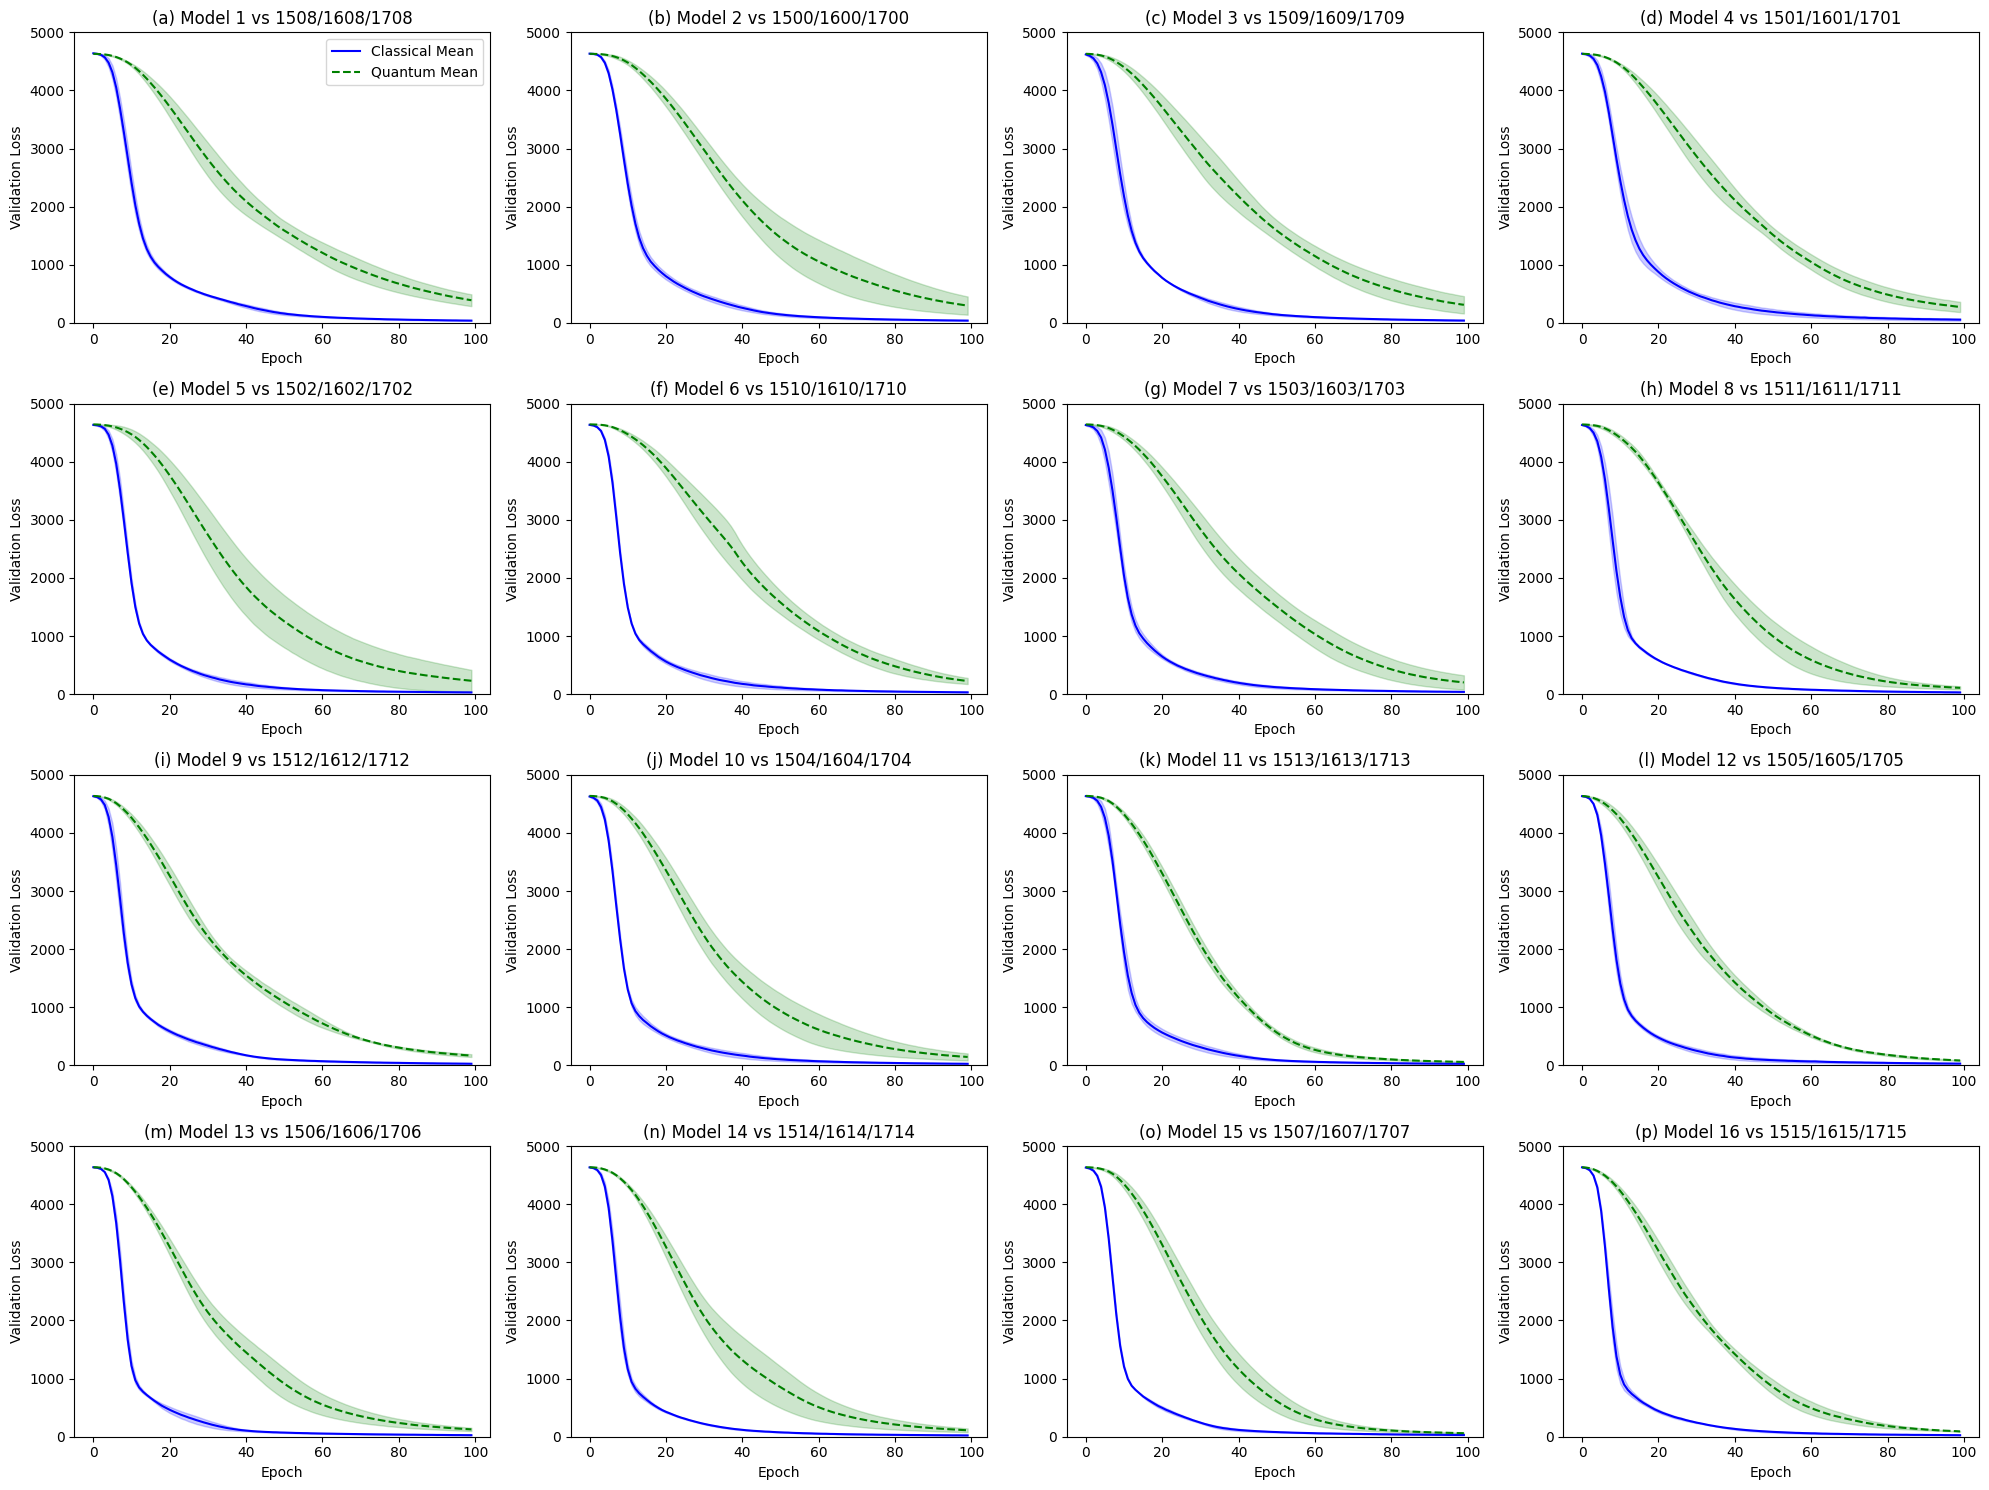

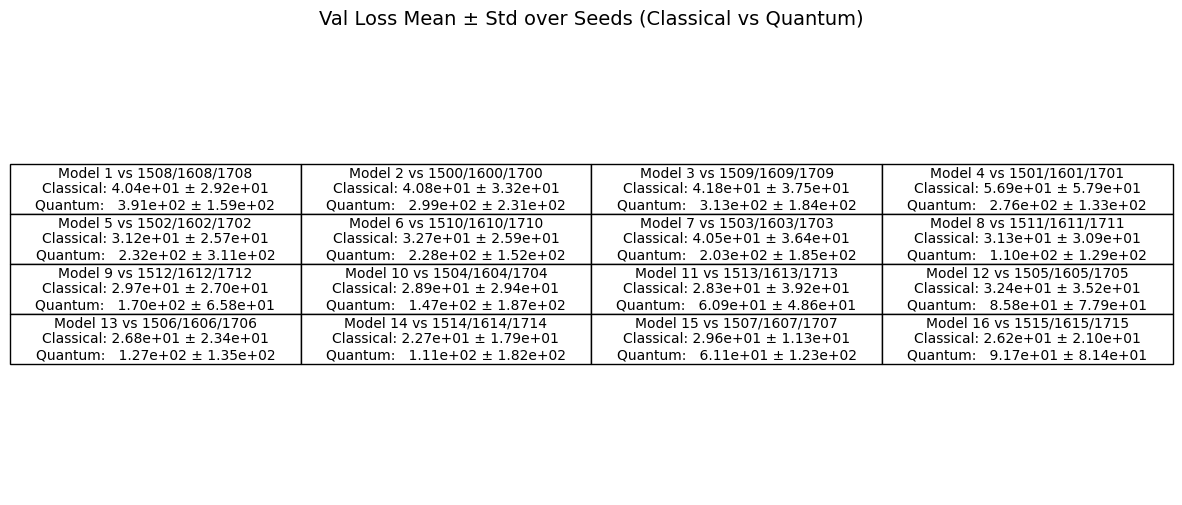

In [37]:
import matplotlib.pyplot as plt
import json
import numpy as np
import os

def impute_nans_with_final_value(arr):
    arr = np.array(arr, dtype=np.float64)
    last_val = np.nan
    for i in range(len(arr)):
        if not np.isnan(arr[i]):
            last_val = arr[i]
        elif not np.isnan(last_val):
            arr[i] = last_val
    arr = np.nan_to_num(arr, nan=0.0)
    return arr.tolist()

def extract_losses(data):
    train, val, epochs = [], [], []
    for entry in data:
        train.append(entry.get("train_loss", np.nan))
        val.append(entry.get("val_loss", np.nan))
        epochs.append(entry.get("epoch"))
    return impute_nans_with_final_value(train), impute_nans_with_final_value(val), epochs

# Model numbers
model_nums0 = list(range(1, 17))
model_nums1 = [1508, 1500, 1509, 1501,
               1502, 1510, 1503, 1511,
               1512, 1504, 1513, 1505,
               1506, 1514, 1507, 1515]
model_nums2 = [i + 100 for i in model_nums1]
model_nums3 = [i + 200 for i in model_nums1]

summary_data = []
fig1, axes = plt.subplots(4, 4, figsize=(20, 15))
loss_ymin, loss_ymax = 0, 5000

for i in range(16):
    row, col = divmod(i, 4)
    ax = axes[row][col]

    model_numx = model_nums0[i]
    model_num1 = model_nums1[i]
    model_num2 = model_nums2[i]
    model_num3 = model_nums3[i]

    classical_paths = [f'ANN_SYN/ANN_SYN_1000/logs/ANN_SYN_1000_{model_numx}_{s}_logs.json' for s in [42, 52, 62]]
    quantum_paths = [f'SYN/SYN_1000/logs/SYN_1000_{m}_{s}_logs.json' for m, s in zip([model_num1, model_num2, model_num3], [42, 52, 62])]

    classical_vals, quantum_vals = [], []
    try:
        for path in classical_paths:
            with open(path) as f:
                _, val, _ = extract_losses(json.load(f))
                classical_vals.append(val)

        for path in quantum_paths:
            with open(path) as f:
                _, val, _ = extract_losses(json.load(f))
                quantum_vals.append(val)

        min_len = 100
        def pad_or_truncate(seq, target_len):
            return seq[:target_len] if len(seq) >= target_len else seq + [seq[-1]] * (target_len - len(seq))

        classical_stack = np.array([pad_or_truncate(v, min_len) for v in classical_vals])
        quantum_stack = np.array([pad_or_truncate(v, min_len) for v in quantum_vals])
        epochs = list(range(min_len))

        c_mean, c_std = np.nanmean(classical_stack, axis=0), np.nanstd(classical_stack, axis=0)
        q_mean, q_std = np.nanmean(quantum_stack, axis=0), np.nanstd(quantum_stack, axis=0)

        summary_data.append({
            "model_nums": (model_numx, model_num1, model_num2, model_num3),
            "classical": (c_mean[-1], c_std[-1], np.mean(c_std)),
            "quantum": (q_mean[-1], q_std[-1], np.mean(q_std))
        })

        ax.plot(epochs, c_mean, label='Classical Mean', color='blue')
        ax.fill_between(epochs, c_mean - c_std, c_mean + c_std, color='blue', alpha=0.2)
        ax.plot(epochs, q_mean, label='Quantum Mean', color='green', linestyle='--')
        ax.fill_between(epochs, q_mean - q_std, q_mean + q_std, color='green', alpha=0.2)

        subplot_label = string.ascii_lowercase[i]
        ax.set_title(f'({subplot_label}) Model {model_numx} vs {model_num1}/{model_num2}/{model_num3}')

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation Loss')
        ax.set_ylim(loss_ymin, loss_ymax)
        if i == 0:
            ax.legend()

    except FileNotFoundError as e:
        ax.set_title("Missing logs")
        ax.axis('off')
        print(f"Missing file: {e}")

fig1.tight_layout()
fig1.savefig("SYN_val_loss_comparison_curves.svg", dpi=600, bbox_inches='tight')

# Create summary table
fig2, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
cell_text = []
for row in range(4):
    cell_row = []
    for col in range(4):
        idx = row * 4 + col
        if idx >= len(summary_data):
            cell_row.append("Missing")
            continue
        entry = summary_data[idx]
        c_mean, c_std, c_avg = entry["classical"]
        q_mean, q_std, q_avg = entry["quantum"]
        mx, m1, m2, m3 = entry["model_nums"]
        cell_row.append(
            f"Model {mx} vs {m1}/{m2}/{m3}\n"
            f"Classical: {c_mean:.2e} ± {c_avg:.2e}\n"
            f"Quantum:   {q_mean:.2e} ± {q_avg:.2e}"
        )
    cell_text.append(cell_row)

table = ax.table(cellText=cell_text, loc='center', cellLoc='center', colWidths=[0.25]*4)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.25, 3)
ax.set_title("Val Loss Mean ± Std over Seeds (Classical vs Quantum)", fontsize=14)
fig2.savefig("SYN_val_loss_comparison_summary_table.svg", dpi=600, bbox_inches='tight')


# QCS plots

## NIFTY DATA QCS

Heatmap

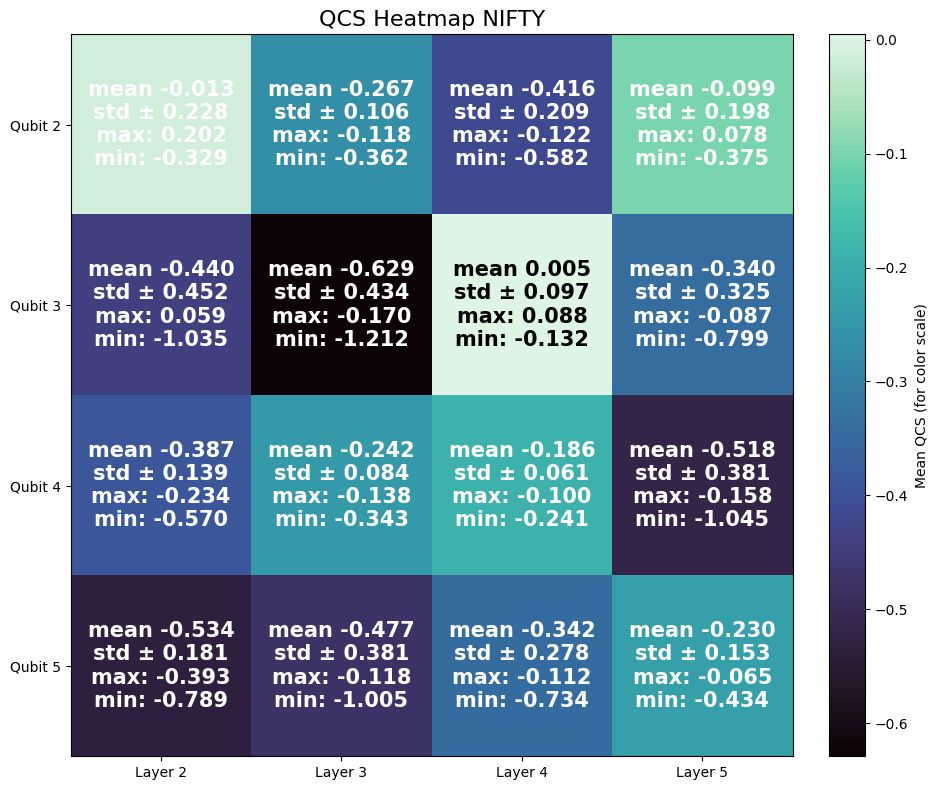

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

def impute_nans_with_final_value(arr):
    arr = np.array(arr, dtype=np.float64)
    last_val = np.nan
    for i in range(len(arr)):
        if not np.isnan(arr[i]):
            last_val = arr[i]
        elif not np.isnan(last_val):
            arr[i] = last_val
    return np.nan_to_num(arr, nan=0.0).tolist()

def extract_losses(data):
    train, val, epochs = [], [], []
    for entry in data:
        train.append(entry.get("train_loss", np.nan))
        val.append(entry.get("val_loss", np.nan))
        epochs.append(entry.get("epoch"))
    return impute_nans_with_final_value(train), impute_nans_with_final_value(val), epochs

model_nums0 = list(range(1, 17))  # Classical model IDs (1-16)
model_nums1 = [1508, 1500, 1509, 1501,
               1502, 1510, 1503, 1511,
               1512, 1504, 1513, 1505,
               1506, 1514, 1507, 1515]
model_nums2 = [m + 100 for m in model_nums1]
model_nums3 = [1608, 1700, 1609, 1701,
               1702, 1610, 1703, 1611,
               1612, 1704, 1613, 1705,
               1706, 1614, 1707, 1615]

qcs_list_all = []

for i in range(16):
    classical_id = model_nums0[i]
    quantum_ids = [model_nums1[i], model_nums2[i], model_nums3[i]]

    classical_paths = [
        f'ANN_NIFTY/ANN_NIFTY_1000/logs/ANN_NIFTY_1000_{classical_id}_{seed}_logs.json'
        for seed in (42, 52, 62)
    ]
    quantum_paths = [
        f'NIFTY/NIFTY_1000/logs/NIFTY_1000_{q_id}_{seed}_logs.json'
        for q_id, seed in zip(quantum_ids, (42, 52, 62))
    ]

    try:
        classical_vals = []
        for path in classical_paths:
            with open(path) as f:
                _, val, _ = extract_losses(json.load(f))
                classical_vals.append(val)

        quantum_vals = []
        for path in quantum_paths:
            with open(path) as f:
                _, val, _ = extract_losses(json.load(f))
                quantum_vals.append(val)

        def pad_or_truncate(seq, target_len=100):
            if len(seq) >= target_len:
                return seq[:target_len]
            else:
                return seq + [seq[-1]] * (target_len - len(seq))

        qcs_vals = []
        for c_vals, q_vals in zip(classical_vals, quantum_vals):
            c_final = pad_or_truncate(c_vals)[-1]
            q_final = pad_or_truncate(q_vals)[-1]
            qcs = (c_final - q_final) / c_final if c_final > 0 else 0
            qcs_vals.append(qcs)

        qcs_list_all.append(qcs_vals)  # Store list of QCS 1,2,3 for each model

    except FileNotFoundError as e:
        qcs_list_all.append([np.nan, np.nan, np.nan])
        print(f"⚠️ Missing file for model {classical_id}: {e}")

# Prepare heatmap with mean ± std, max, min values as text in each cell
fig, ax = plt.subplots(figsize=(10, 8))

mean_qcs_vals = [np.nanmean(vals) if vals is not None else np.nan for vals in qcs_list_all]
heatmap_values = np.array(mean_qcs_vals).reshape(4, 4)

cmap = sns.color_palette("mako", as_cmap=True)
im = ax.imshow(heatmap_values, cmap=cmap)

for i in range(4):
    for j in range(4):
        qcs_vals = qcs_list_all[i*4 + j]
        if any(np.isnan(qcs_vals)):
            text = "N/A"
            text_color = "red"
        else:
            mean_val = np.mean(qcs_vals)
            std_val = np.std(qcs_vals)
            max_val = np.max(qcs_vals)
            min_val = np.min(qcs_vals)

            text = (f"mean {mean_val:.3f}\n"
                    f"std ± {std_val:.3f}\n"
                    f"max: {max_val:.3f}\n"
                    f"min: {min_val:.3f}")

            text_color = "white" if heatmap_values[i, j] < 0.5 * np.nanmax(heatmap_values) else "black"

        ax.text(j, i, text, ha='center', va='center', color=text_color, fontsize=15, fontweight='bold')

# Axis labels
ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(4))
ax.set_xticklabels([f'Layer {i}' for i in range(2, 6)])  # Layers 2 to 5
ax.set_yticklabels([f'Qubit {i}' for i in range(2, 6)])  # Qubits 2 to 5

ax.set_title("QCS Heatmap NIFTY", fontsize=16)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Mean QCS (for color scale)')

plt.tight_layout()
fig.savefig("nifty_qcs_heatmap.svg", dpi=600, bbox_inches='tight')

plt.show()


QCS trend with layers (depth)

In [101]:
import numpy as np
from scipy.stats import pearsonr

# Convert each [qcs1, qcs2, qcs3] to its mean
mean_qcs_list = [np.mean(vals) for vals in qcs_list_all]

# Reshape to 4x4
reshaped_means = np.array(mean_qcs_list).reshape(4, 4)

qubits = np.array([2, 3, 4, 5])
layers = np.array([2, 3, 4, 5])

# Average across rows (axis=1) → average per qubit across layers
avg_across_columns = reshaped_means.mean(axis=1)  # shape (4,) corresponds to qubits

# Average across columns (axis=0) → average per layer across qubits
avg_across_rows = reshaped_means.mean(axis=0)     # shape (4,) corresponds to layers

# Correlation 1: avg_across_columns vs qubits
corr_qubit, p_qubit = pearsonr(qubits, avg_across_columns)
print(avg_across_columns)
# Correlation 2: avg_across_rows vs layers
corr_layer, p_layer = pearsonr(layers, avg_across_rows)

print(f"Correlation between qubit and average across layers: {corr_qubit:.4f} (p = {p_qubit:.4g})")
print(f"Correlation between layer and average across qubits: {corr_layer:.4f} (p = {p_layer:.4g})")


[-0.19878354 -0.35122412 -0.33331833 -0.39582707]
Correlation between qubit and average across layers: -0.8722 (p = 0.1278)
Correlation between layer and average across qubits: 0.5566 (p = 0.4434)


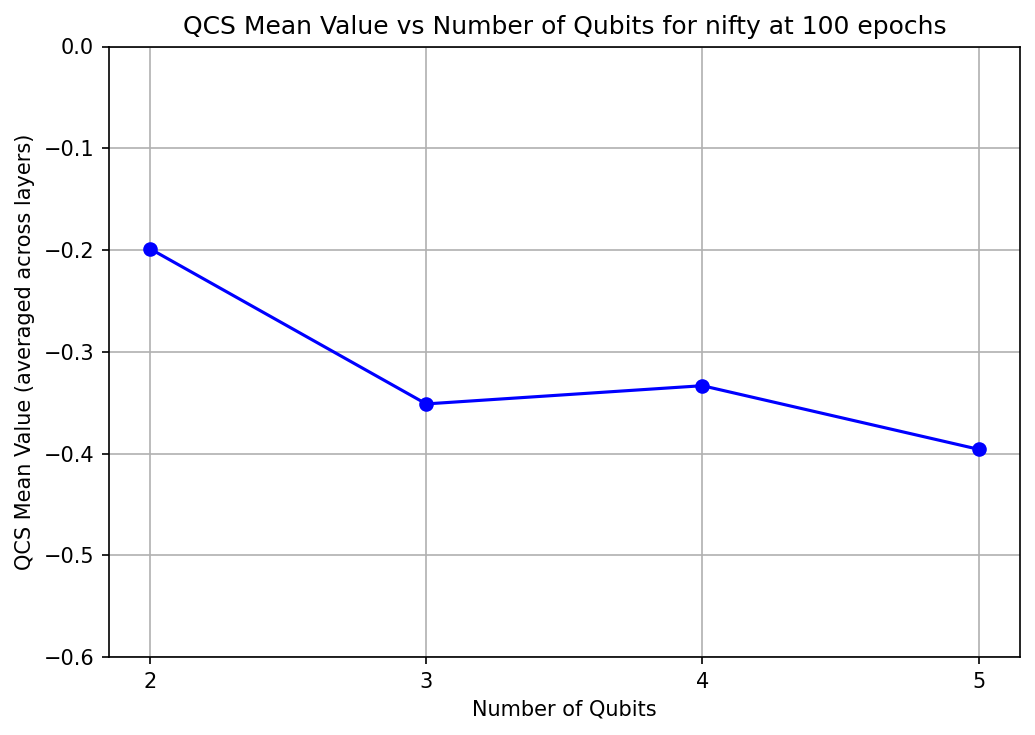

In [103]:
import numpy as np
import matplotlib.pyplot as plt

data = reshaped_means  # Assuming this is the list of QCS values for each model
qubits = np.array([2, 3, 4, 5])

# Average across columns (layers)
avg_across_columns = data.mean(axis=1)

# Plotting
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(qubits, avg_across_columns, marker='o', linestyle='-', color='blue')

plt.title('QCS Mean Value vs Number of Qubits for nifty at 100 epochs')
plt.xlabel('Number of Qubits')
plt.ylabel('QCS Mean Value (averaged across layers)')
plt.grid(True)
plt.xticks(qubits)  # Make sure only 2,3,4,5 show on x-axis
# Set y-axis limits (custom scale)
plt.ylim(-0.6, 0)  # Adjust these numbers to your desired scale

plt.savefig("QCS_over_qubit_nifty_100epoch.svg", dpi=600, bbox_inches='tight')

plt.tight_layout()
plt.show()


QCS trend with qubits (width)

## SYN DATA QCS

Heatmap

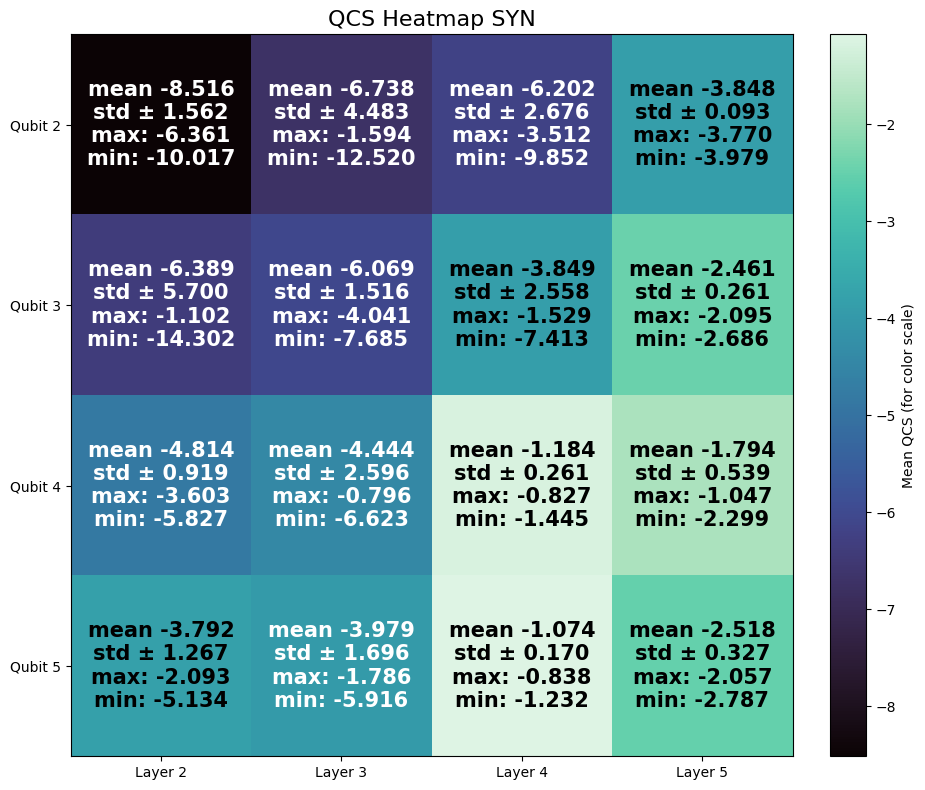

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from matplotlib.colors import Normalize

def impute_nans_with_final_value(arr):
    arr = np.array(arr, dtype=np.float64)
    last_val = np.nan
    for i in range(len(arr)):
        if not np.isnan(arr[i]):
            last_val = arr[i]
        elif not np.isnan(last_val):
            arr[i] = last_val
    return np.nan_to_num(arr, nan=0.0).tolist()

def extract_losses(data):
    train, val, epochs = [], [], []
    for entry in data:
        train.append(entry.get("train_loss", np.nan))
        val.append(entry.get("val_loss", np.nan))
        epochs.append(entry.get("epoch"))
    return impute_nans_with_final_value(train), impute_nans_with_final_value(val), epochs

model_nums0 = list(range(1, 17))  # Classical model IDs (1–16)
model_nums1 = [1508, 1500, 1509, 1501,
               1502, 1510, 1503, 1511,
               1512, 1504, 1513, 1505,
               1506, 1514, 1507, 1515]
model_nums2 = [m + 100 for m in model_nums1]
model_nums3 = [m + 200 for m in model_nums1]

qcs_list_all = []

for i in range(16):
    classical_id = model_nums0[i]
    quantum_ids = [model_nums1[i], model_nums2[i], model_nums3[i]]

    classical_paths = [
        f'ANN_SYN/ANN_SYN_1000/logs/ANN_SYN_1000_{classical_id}_{seed}_logs.json'
        for seed in (42, 52, 62)
    ]
    quantum_paths = [
        f'SYN/SYN_1000/logs/SYN_1000_{q_id}_{seed}_logs.json'
        for q_id, seed in zip(quantum_ids, (42, 52, 62))
    ]

    try:
        classical_vals = []
        for path in classical_paths:
            with open(path) as f:
                _, val, _ = extract_losses(json.load(f))
                classical_vals.append(val)

        quantum_vals = []
        for path in quantum_paths:
            with open(path) as f:
                _, val, _ = extract_losses(json.load(f))
                quantum_vals.append(val)

        def pad_or_truncate(seq, target_len=100):
            if len(seq) >= target_len:
                return seq[:target_len]
            else:
                return seq + [seq[-1]] * (target_len - len(seq))

        qcs_vals = []
        for c_vals, q_vals in zip(classical_vals, quantum_vals):
            c_final = pad_or_truncate(c_vals)[-1]
            q_final = pad_or_truncate(q_vals)[-1]
            qcs = (c_final - q_final) / c_final if c_final > 0 else 0
            qcs_vals.append(qcs)

        qcs_list_all.append(qcs_vals)  # Store list of QCS 1,2,3 for each model

    except FileNotFoundError as e:
        qcs_list_all.append([np.nan, np.nan, np.nan])
        print(f"⚠️ Missing file for model {classical_id}: {e}")

# Prepare heatmap with mean ± std, max, min values as text in each cell
fig, ax = plt.subplots(figsize=(10, 8))

mean_qcs_vals = [np.nanmean(vals) if vals is not None else np.nan for vals in qcs_list_all]
heatmap_values = np.array(mean_qcs_vals).reshape(4, 4)

# Setup colormap and normalization
cmap = sns.color_palette("mako", as_cmap=True)
norm = Normalize(vmin=np.nanmin(heatmap_values), vmax=np.nanmax(heatmap_values))
im = ax.imshow(heatmap_values, cmap=cmap, norm=norm)

for i in range(4):
    for j in range(4):
        qcs_vals = qcs_list_all[i*4 + j]
        if any(np.isnan(qcs_vals)):
            text = "N/A"
            text_color = "red"
        else:
            mean_val = np.mean(qcs_vals)
            std_val = np.std(qcs_vals)
            max_val = np.max(qcs_vals)
            min_val = np.min(qcs_vals)

            text = (f"mean {mean_val:.3f}\n"
                    f"std ± {std_val:.3f}\n"
                    f"max: {max_val:.3f}\n"
                    f"min: {min_val:.3f}")

            # Get RGB from normalized heatmap value
            color = cmap(norm(heatmap_values[i, j]))
            r, g, b = color[:3]
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            text_color = "white" if luminance < 0.5 else "black"

        ax.text(j, i, text, ha='center', va='center', color=text_color, fontsize=15, fontweight='bold')

# Axis labels
ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(4))
ax.set_xticklabels([f'Layer {i}' for i in range(2, 6)])
ax.set_yticklabels([f'Qubit {i}' for i in range(2, 6)])

ax.set_title("QCS Heatmap SYN", fontsize=16)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Mean QCS (for color scale)')

plt.tight_layout()
fig.savefig("syn_qcs_heatmap.svg", dpi=600, bbox_inches='tight')

plt.show()


QCS trend with layers (depth)

In [97]:
import numpy as np
from scipy.stats import pearsonr

# Convert each [qcs1, qcs2, qcs3] to its mean
mean_qcs_list = [np.mean(vals) for vals in qcs_list_all]
print(mean_qcs_list)
# Reshape to 4x4
reshaped_means = np.array(mean_qcs_list).reshape(4, 4)

qubits = np.array([2, 3, 4, 5])
layers = np.array([2, 3, 4, 5])

# Average across rows (axis=1) → average per qubit across layers
avg_across_columns = reshaped_means.mean(axis=1)  # shape (4,) corresponds to qubits

# Average across columns (axis=0) → average per layer across qubits
avg_across_rows = reshaped_means.mean(axis=0)     # shape (4,) corresponds to layers

# Correlation 1: avg_across_columns vs qubits
corr_qubit, p_qubit = pearsonr(qubits, avg_across_columns)
print(avg_across_columns)
print(avg_across_rows)
# Correlation 2: avg_across_rows vs layers
corr_layer, p_layer = pearsonr(layers, avg_across_rows)

print(f"Correlation between qubit and average across layers: {corr_qubit:.4f} (p = {p_qubit:.4g})")
print(f"Correlation between layer and average across qubits: {corr_layer:.4f} (p = {p_layer:.4g})")


[-8.515662789580738, -6.738086953329593, -6.201558636808241, -3.84848639587554, -6.388757535834365, -6.068899388760304, -3.8490828864770505, -2.460572207890663, -4.814135216114022, -4.44373454776914, -1.18351116112178, -1.7935068085758339, -3.791916158227085, -3.9794362025523395, -1.0737759663341249, -2.517639977854708]
[-6.32594869 -4.691828   -3.05872193 -2.84069208]
[-5.87761792 -5.30753927 -3.07698216 -2.65505135]
Correlation between qubit and average across layers: 0.9612 (p = 0.03877)
Correlation between layer and average across qubits: 0.9597 (p = 0.04032)


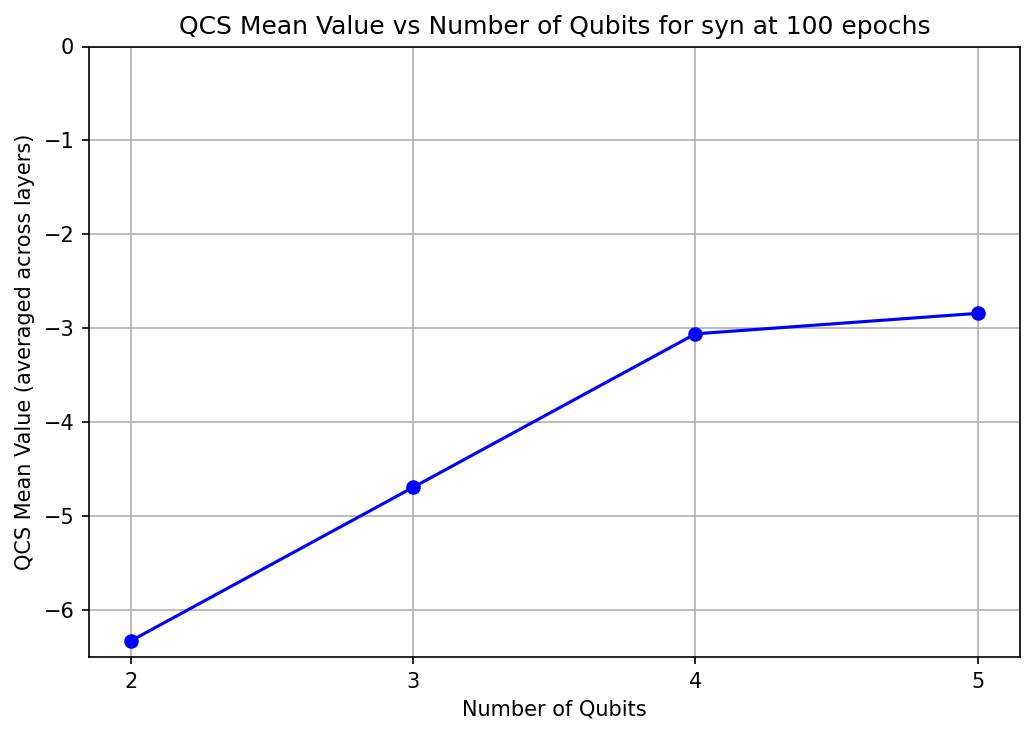

In [98]:
import numpy as np
import matplotlib.pyplot as plt

data = reshaped_means  # Assuming this is the list of QCS values for each model
qubits = np.array([2, 3, 4, 5])

# Average across columns (layers)
avg_across_columns = data.mean(axis=1)

# Plotting
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(qubits, avg_across_columns, marker='o', linestyle='-', color='blue')

plt.title('QCS Mean Value vs Number of Qubits for syn at 100 epochs')
plt.xlabel('Number of Qubits')
plt.ylabel('QCS Mean Value (averaged across layers)')
plt.grid(True)
plt.xticks(qubits)  # Make sure only 2,3,4,5 show on x-axis
# Set y-axis limits (custom scale)
plt.ylim(-6.5, 0)  # Adjust these numbers to your desired scale
plt.savefig("QCS_over_qubit_syn_100epoch.svg", dpi=600, bbox_inches='tight')

plt.tight_layout()
plt.show()


QCS trend with qubits (width)

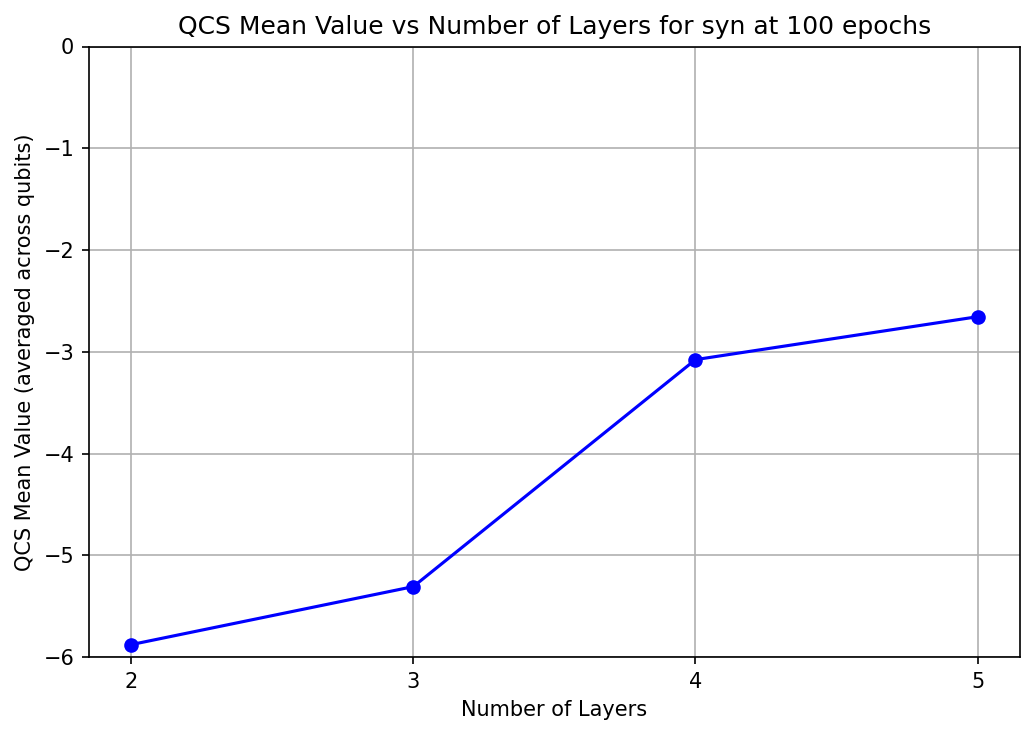

In [99]:
import numpy as np
import matplotlib.pyplot as plt

data = reshaped_means  # Assuming this is the list of QCS values for each model
qubits = np.array([2, 3, 4, 5])

# Average across columns (layers)
avg_across_columns = data.mean(axis=0)

# Plotting
plt.figure(figsize=(7, 5), dpi=150)
plt.plot(qubits, avg_across_columns, marker='o', linestyle='-', color='blue')

plt.title('QCS Mean Value vs Number of Layers for syn at 100 epochs')
plt.xlabel('Number of Layers')
plt.ylabel('QCS Mean Value (averaged across qubits)')
plt.grid(True)
plt.xticks(qubits)  # Make sure only 2,3,4,5 show on x-axis
plt.ylim(-6, 0)  # Adjust these numbers to your desired scale

plt.savefig("QCS_over_layer_syn_100epoch.svg", dpi=600, bbox_inches='tight')

plt.tight_layout()
plt.show()
